# 2022-09-01_koseki_a_efp.dat & 2022-09-01_koseki_a_fgh.dat

26-Jul-25 00:51:56: del_data: No valid tplot variables found, returning
26-Jul-25 00:51:56: /tmp/ipykernel_1494/3509751672.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_E_1 = pd.read_csv(

26-Jul-25 00:51:58: /tmp/ipykernel_1494/3509751672.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_E_2 = pd.read_csv(

26-Jul-25 00:51:58: /tmp/ipykernel_1494/3509751672.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_B_1 = pd.read_csv(

26-Jul-25 00:51:59: /tmp/ipykernel_1494/3509751672.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_B_2 = pd.read_csv(



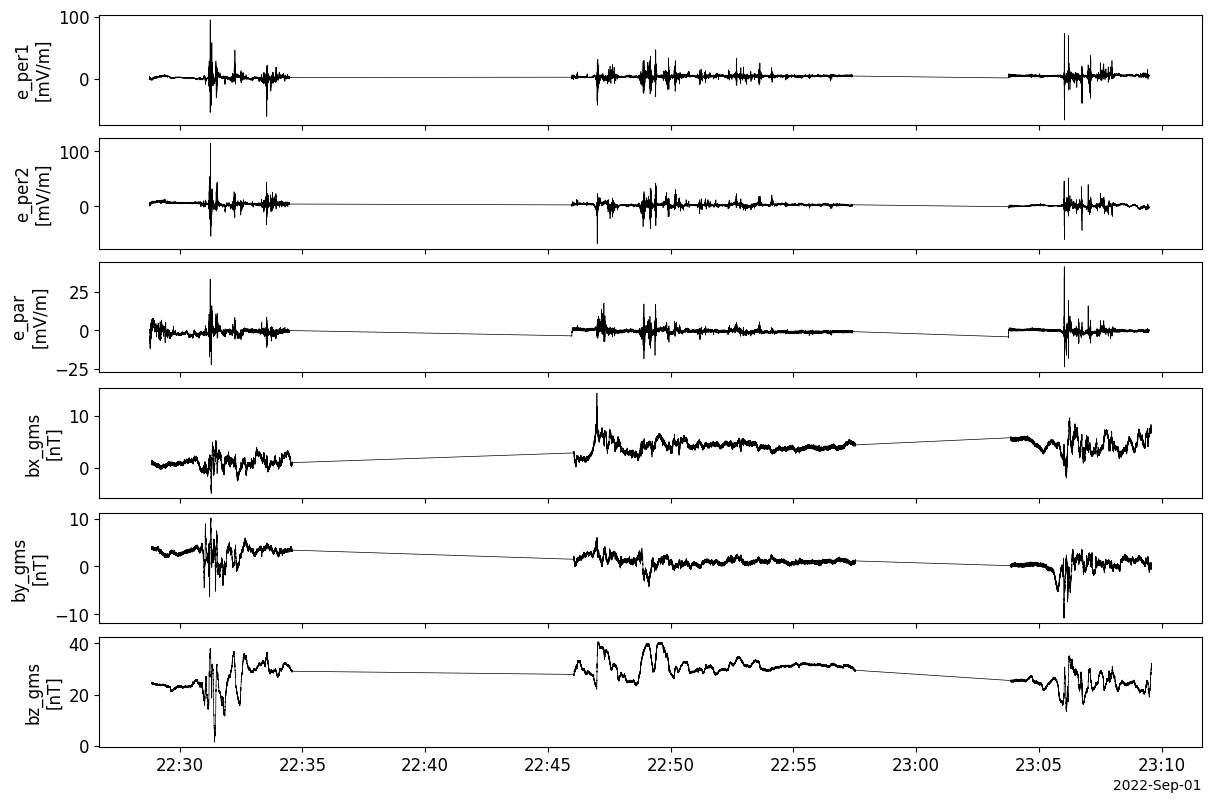

In [1]:
import pandas as pd
import numpy as np
import pytplot as pt
import xarray as xr

pt.del_data('*')

dir_name = f'/mnt/j/observation_data/THEMIS_A_from_Artemyev'

file_name_E_1 = f'{dir_name}/2022-09-01_koseki_a_efp_22-23.dat'
file_name_E_2 = f'{dir_name}/2022-09-01_koseki_a_efp_23-24.dat'
file_name_B_1 = f'{dir_name}/2022-09-01_koseki_a_fgh_22-23.dat'
file_name_B_2 = f'{dir_name}/2022-09-01_koseki_a_fgh_23-24.dat'

df_E_1 = pd.read_csv(
    file_name_E_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_E_2 = pd.read_csv(
    file_name_E_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_E = pd.concat([df_E_1, df_E_2], ignore_index=True)

df_B_1 = pd.read_csv(
    file_name_B_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_B_2 = pd.read_csv(
    file_name_B_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_B = pd.concat([df_B_1, df_B_2], ignore_index=True)

time_E = df_E['time'].to_numpy(dtype='datetime64[ns]')
time_B = df_B['time'].to_numpy(dtype='datetime64[ns]')

for col in ['e_per1', 'e_per2', 'e_par']:
    pt.store_data(
        col,
        data={'x': time_E, 'y': df_E[col].to_numpy()}   # FAC
    )
    pt.options(col, 'ytitle', col)
    pt.options(col, 'ysubtitle', '[mV/m]')

for col in ['bx_gms', 'by_gms', 'bz_gms']:
    pt.store_data(
        col,
        data={'x': time_B, 'y': df_B[col].to_numpy()}   # GMS
    )
    pt.options(col, 'ytitle', col)
    pt.options(col, 'ysubtitle', '[nT]')

# -------------------------------
# 3. プロット
# -------------------------------
pt.tplot(['e_per1', 'e_per2', 'e_par', 'bx_gms', 'by_gms', 'bz_gms'])

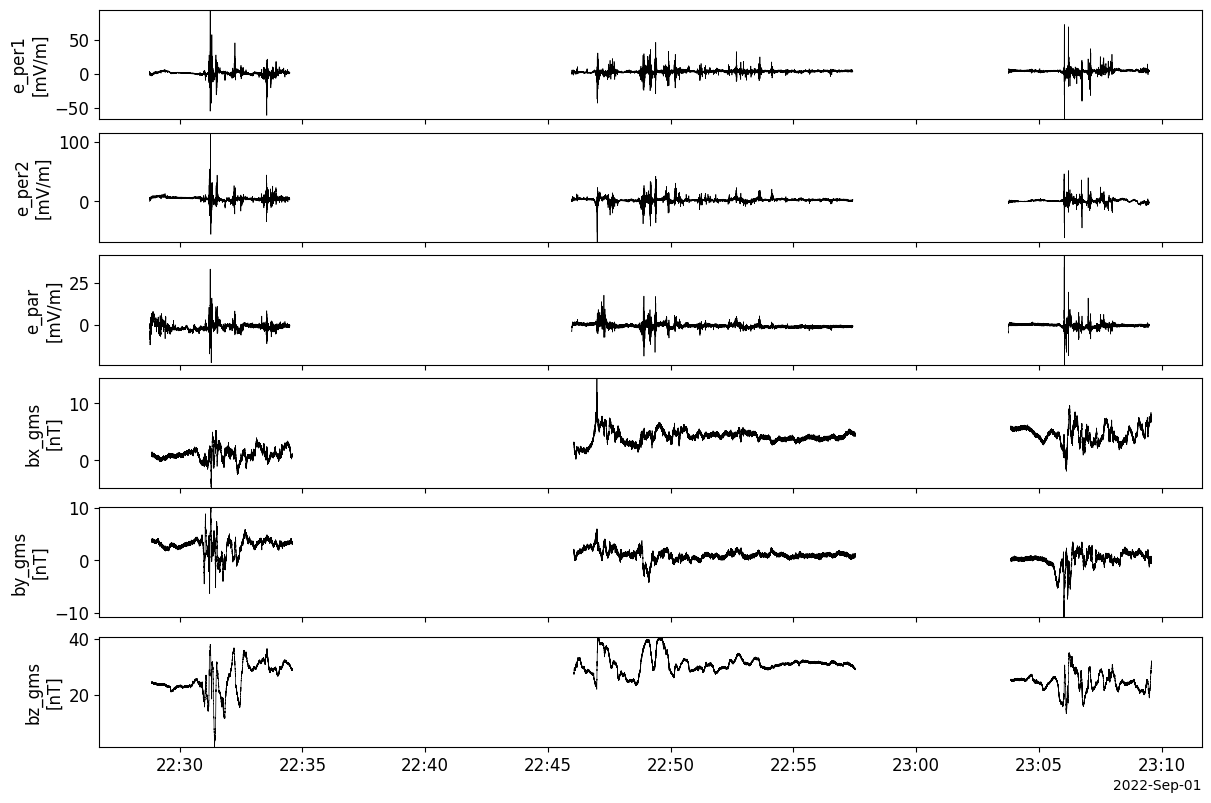

In [2]:
import numpy as np
import pytplot as pt
gap_thr = np.timedelta64(10, 's')

# ---------- 1. 電場チャンク ----------------------------------
t_ref_E = pt.data_quants['e_per1'].time.values
is_new_E = np.concatenate(([True], np.diff(t_ref_E) > gap_thr))
chunk_E  = np.cumsum(is_new_E) - 1

# ---------- 2. 磁場チャンク ----------------------------------
t_ref_B = pt.data_quants['bx_gms'].time.values
is_new_B = np.concatenate(([True], np.diff(t_ref_B) > gap_thr))
chunk_B  = np.cumsum(is_new_B) - 1

# ---------- 3. 分割ループ ------------------------------------
vars_E = ['e_per1','e_per2','e_par']
vars_B = ['bx_gms','by_gms','bz_gms']

def split_and_store(var_list, t_ref, chunk_id):
    for v in var_list:
        da   = pt.data_quants[v]
        for k in np.unique(chunk_id):
            sel = chunk_id == k
            if sel.sum() == 0:
                continue
            new = f'{v}_seg{k}'
            pt.store_data(new,
                          data={'x': t_ref[sel], 'y': da.values[sel]})
            unit = '[mV/m]' if v.startswith('e_') else '[nT]'
            pt.options(new,'ytitle',v); pt.options(new,'ysubtitle',unit)

split_and_store(vars_E, t_ref_E, chunk_E)
split_and_store(vars_B, t_ref_B, chunk_B)

# ---------- 4. まとめ変数 ------------------------------------
def make_all(base):
    pt.store_data(f'{base}_all', data=pt.tnames(f'{base}_seg*'))

for base in vars_E + vars_B:
    make_all(base)

# ---------- 5. 描画 ------------------------------------------
pt.tplot(['e_per1_all','e_per2_all','e_par_all',
          'bx_gms_all','by_gms_all','bz_gms_all'])


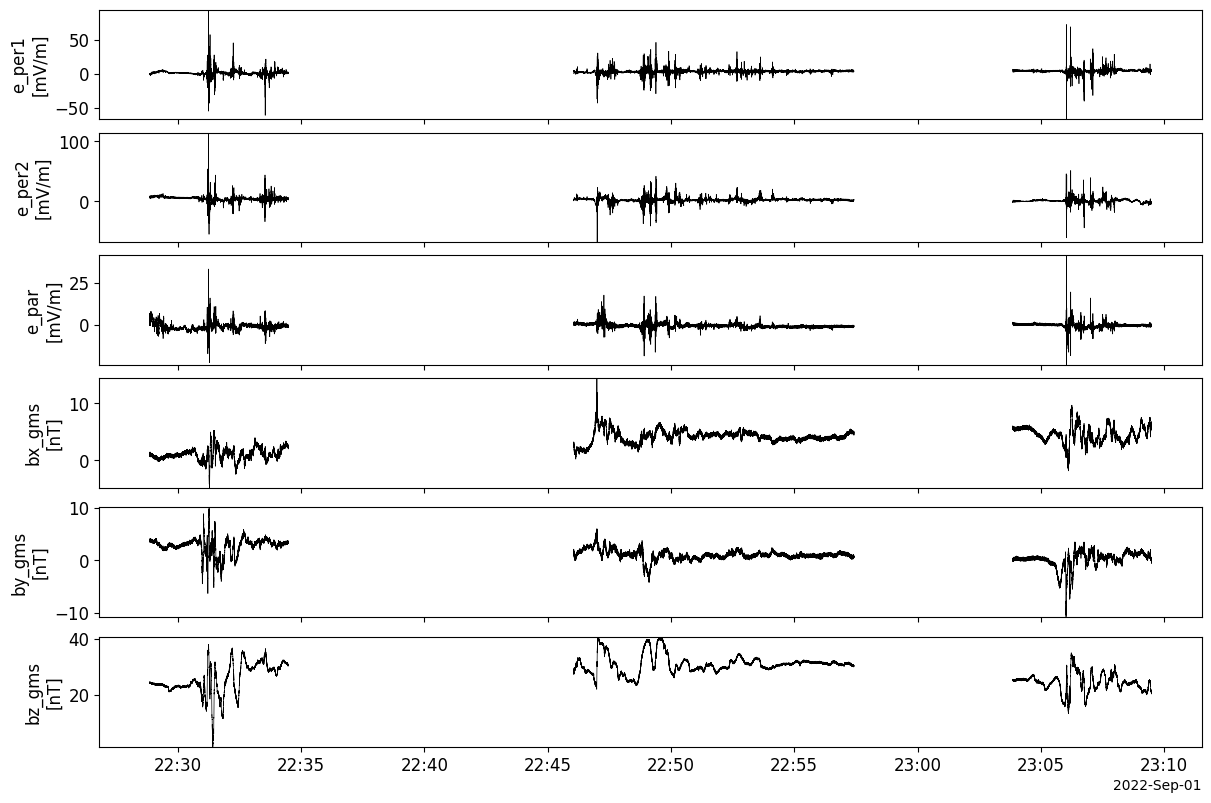

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 173016)
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T23:03:51.404876 ... 2022-09...
Data variables:
    e_per1   (time) float64 1MB 3.09 3.09 3.089 3.089 ... 4.273 4.264 4.162
    e_per2   (time) float64 1MB -1.688 -1.71 -1.731 ... -1.986 -2.017 -1.942
    e_par    (time) float64 1MB 0.8954 0.8986 0.9041 ... 0.1494 0.1498 0.1248
    bx_gms   (time) float64 1MB 5.832 5.798 5.764 5.73 ... 6.651 6.685 6.719
    by_gms   (time) float64 1MB 0.156 0.1759 0.1959 ... -0.4951 -0.4543 -0.4136
    bz_gms   (time) float64 1MB 25.5 25.49 25.48 25.48 ... 20.58 20.58 20.57


In [3]:
import numpy as np
import xarray as xr
import pytplot as pt

# ────────────────────────────────────────────────
# 0. セグメント名リストを取得
# ────────────────────────────────────────────────
seg_ids = sorted({v.split('_seg')[-1]                      # {'0','1',...}
                  for v in pt.tnames('e_per1_seg*')})

# まとめ用リスト（後で overplot するために使う）
e1_all, e2_all, ep_all = [], [], []
bx_all, by_all, bz_all = [], [], []

# ────────────────────────────────────────────────
# 1. 各セグメントごとに処理
# ────────────────────────────────────────────────
for sid in seg_ids:
    # TVar 取り出し → pandas DataFrame へ （xarray に変換するため）
    def to_df(var):           # var = 'e_per1_seg0' など
        dq = pt.data_quants[var]
        return pd.DataFrame({'time': dq.time.values,
                             var.split('_seg')[0]: dq.values})

    df_E = (to_df(f'e_per1_seg{sid}')
            .merge(to_df(f'e_per2_seg{sid}'), on='time')
            .merge(to_df(f'e_par_seg{sid}'),  on='time'))

    df_B = (to_df(f'bx_gms_seg{sid}')
            .merge(to_df(f'by_gms_seg{sid}'), on='time')
            .merge(to_df(f'bz_gms_seg{sid}'), on='time'))

    # ---- xarray Dataset へ ----
    ds_E = xr.Dataset({k:(('time',), df_E[k].to_numpy(dtype=float))
                       for k in ['e_per1','e_per2','e_par']},
                      coords={'time': df_E['time'].to_numpy('datetime64[ns]')})

    ds_B = xr.Dataset({k:(('time',), df_B[k].to_numpy(dtype=float))
                       for k in ['bx_gms','by_gms','bz_gms']},
                      coords={'time': df_B['time'].to_numpy('datetime64[ns]')})

    # ---- B を E の時刻へ線形補間 ----
    ds_B_i  = ds_B.interp(time=ds_E.time, method='linear')
    ds_merged = xr.merge([ds_E, ds_B_i])
    ds_merged = ds_merged.dropna(dim='time', how='any', subset=['e_per1','e_per2','e_par', 'bx_gms','by_gms','bz_gms'])

    # ---- TVar 登録（seg ID を引き継ぐ） ----
    for var in ds_merged.data_vars:
        new_name = f'{var}_seg{sid}_i'          # 例: e_per1_seg0_i
        pt.store_data(new_name,
                      data={'x': ds_merged.time.values,
                            'y': ds_merged[var].values})
        unit = '[mV/m]' if var.startswith('e_') else '[nT]'
        pt.options(new_name, 'ytitle', var)
        pt.options(new_name, 'ysubtitle', unit)

        # まとめリストへ追加
        if   var == 'e_per1': e1_all.append(new_name)
        elif var == 'e_per2': e2_all.append(new_name)
        elif var == 'e_par' : ep_all.append(new_name)
        elif var == 'bx_gms': bx_all.append(new_name)
        elif var == 'by_gms': by_all.append(new_name)
        elif var == 'bz_gms': bz_all.append(new_name)

# ────────────────────────────────────────────────
# 2. overplot 用の “まとめ変数” を 6 つ作成
# ────────────────────────────────────────────────
pt.store_data('e_per1_all_i', data=e1_all)
pt.store_data('e_per2_all_i', data=e2_all)
pt.store_data('e_par_all_i',  data=ep_all)
pt.store_data('bx_gms_all_i', data=bx_all)
pt.store_data('by_gms_all_i', data=by_all)
pt.store_data('bz_gms_all_i', data=bz_all)

# ────────────────────────────────────────────────
# 3. プロット（6 パネル、各パネルに全セグメントが重なって表示）
# ────────────────────────────────────────────────
pt.tplot(['e_per1_all_i','e_per2_all_i','e_par_all_i',
          'bx_gms_all_i','by_gms_all_i','bz_gms_all_i'])

print(ds_merged)


In [4]:
import pandas as pd
import pytplot as pt
import xarray as xr
import numpy as np

file_name_fgm_1 = f'{dir_name}/2022-09-01_koseki_tha_fgm_22-23.dat'
file_name_fgm_2 = f'{dir_name}/2022-09-01_koseki_tha_fgm_23-24.dat'

df_fgm_1 = pd.read_csv(
    file_name_fgm_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm_2 = pd.read_csv(
    file_name_fgm_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm = pd.concat([df_fgm_1, df_fgm_2], ignore_index=True)

df_fgm_gms = df_fgm[['time', 'bx_gms', 'by_gms', 'bz_gms']].copy()
df_fgm_gms['time'] = df_fgm_gms['time'].astype('datetime64[ns]')

ds_fgm_gms = xr.Dataset({
    'bx_gms': ('time', df_fgm_gms['bx_gms'].to_numpy(dtype=float)),
    'by_gms': ('time', df_fgm_gms['by_gms'].to_numpy(dtype=float)),
    'bz_gms': ('time', df_fgm_gms['bz_gms'].to_numpy(dtype=float))
}, coords={'time': df_fgm_gms['time'].to_numpy('datetime64[ns]')})

ds_fgm_gms

26-Jul-25 00:52:14: /tmp/ipykernel_1494/4245744784.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_fgm_1 = pd.read_csv(

26-Jul-25 00:52:14: /tmp/ipykernel_1494/4245744784.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_fgm_2 = pd.read_csv(



<xarray.Dataset> Size: 63kB
Dimensions:  (time: 1970)
Coordinates:
  * time     (time) datetime64[ns] 16kB 2022-09-01T22:00:02 ... 2022-09-01T23...
Data variables:
    bx_gms   (time) float64 16kB -9.791 -9.808 -9.703 ... 5.993 6.253 6.111
    by_gms   (time) float64 16kB -0.6599 -0.5948 -0.7933 ... -6.148 -6.204
    bz_gms   (time) float64 16kB 38.07 37.98 38.03 37.87 ... 21.02 21.18 21.03

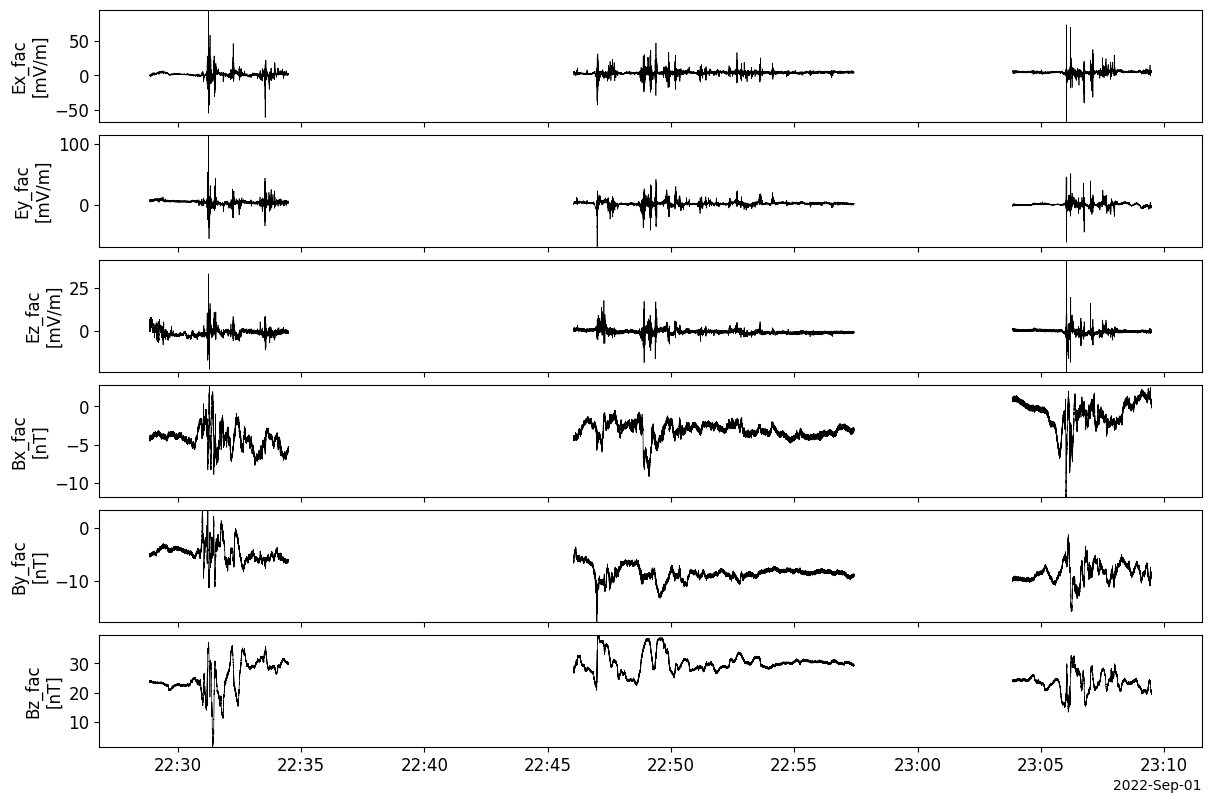

In [5]:
import numpy as np
import xarray as xr
import pytplot as pt

def gms_to_fac(ds_hf: xr.Dataset, ds_lf: xr.Dataset,
               window_sec=100.0) -> tuple[xr.Dataset, xr.DataArray]:
    # ---------- 1. <B> の移動平均 (低周波) ---------------------------
    t_lf   = ds_lf.time.values
    dt     = (t_lf[1]-t_lf[0]).astype('timedelta64[ns]').astype(float)*1e-9
    win    = int(window_sec/dt)

    B_lf   = np.stack([ds_lf[k].values for k in ['bx_gms','by_gms','bz_gms']], axis=1)
    B_avg  = np.vstack([np.nanmean(B_lf[max(i-win//2,0):i+win//2+1], axis=0)
                        for i in range(len(B_lf))])        # (N_lf,3)

    # ---------- 2. FAC 基底 (NumPy) ---------------------------------
    z0 = np.array([0.,0.,1.])
    e2 = np.cross(z0, B_avg)            # (N,3)
    e1 = np.cross(e2, B_avg)
    def _norm(v): return v / np.linalg.norm(v, axis=1, keepdims=True)
    e1h, e2h, e3h = map(_norm, (e1,e2,B_avg))

    R_np = np.stack([e1h, e2h, e3h], axis=2)   # (N_lf,3,3)

    # ---------- 3. DataArray 化して高周波へ補間 -----------------------
    R_da = xr.DataArray(R_np, dims=('time','row','col'),
                        coords={'time': t_lf, 'row':[0,1,2], 'col':[0,1,2]})
    R_hf = R_da.interp(time=ds_hf.time)         # (N_hf,3,3)

    # ---------- 4. B を回して FAC へ --------------------------------
    B_gms_hf = np.stack([ds_hf[k].values for k in ['bx_gms','by_gms','bz_gms']], axis=1)
    B_fac_np = np.einsum('tij,tj->ti', R_hf.values, B_gms_hf)  # (N_hf,3)

    # ---------- 5. Dataset に格納 -----------------------------------
    ds_out = xr.Dataset(
        data_vars=dict(
            Ex_fac = (('time'), ds_hf['e_per1'].values),
            Ey_fac = (('time'), ds_hf['e_per2'].values),
            Ez_fac = (('time'), ds_hf['e_par' ].values),
            Bx_fac = (('time'), B_fac_np[:,0]),
            By_fac = (('time'), B_fac_np[:,1]),
            Bz_fac = (('time'), B_fac_np[:,2]),
        ),
        coords=dict(time=ds_hf.time)
    )
    return ds_out, R_hf

# ------------------------------------------------------------
# 0. seg ID を列挙（e_per1_seg* がすでに存在している想定）
# ------------------------------------------------------------
seg_ids = sorted({n.split('_seg')[1].split('_')[0] for n in pt.tnames('e_per1_seg*_i')})

# FAC 変換後の TVar をまとめておくリスト
Ex_all, Ey_all, Ez_all = [], [], []
Bx_all, By_all, Bz_all = [], [], []

R_dict = {}

# ------------------------------------------------------------
# 1. segment ごとに DSI→FAC 変換
# ------------------------------------------------------------
for sid in seg_ids:
    # ------- E と B の DataFrame 取得 -------
    def to_df(var):
        dq = pt.data_quants[f'{var}_seg{sid}']
        base = var.split('_seg')[0]           # e_per1 等
        return pd.DataFrame({'time': dq.time.values,
                             base: dq.values})

    df_E = (to_df('e_per1')
            .merge(to_df('e_per2'), on='time')
            .merge(to_df('e_par'),  on='time'))
    df_B = (to_df('bx_gms')
            .merge(to_df('by_gms'), on='time')
            .merge(to_df('bz_gms'), on='time'))

    # ------- xarray Dataset に変換 -------
    ds_E = xr.Dataset({k:(('time',), df_E[k]) for k in ['e_per1','e_per2','e_par']},
                      coords={'time': df_E['time'].to_numpy('datetime64[ns]')})
    ds_B = xr.Dataset({k:(('time',), df_B[k]) for k in ['bx_gms','by_gms','bz_gms']},
                      coords={'time': df_B['time'].to_numpy('datetime64[ns]')})

    # ------- B を E 時刻へ線形補間してマージ -------
    ds_merged = xr.merge([ds_E, ds_B.interp(time=ds_E.time, method='linear')])

    # ------- FAC 変換 -------
    ds_fac, Rotational_tensor = gms_to_fac(ds_merged, ds_fgm_gms, window_sec=100.0)

    R_dict[f'R_seg{sid}'] = {
        'R':   Rotational_tensor,          # (N,3,3) np.ndarray
        'time': ds_fac.time.values         # (N,)   datetime64[ns]
    }

    ds_fac = ds_fac.dropna(dim='time', how='any', subset=['Ex_fac','Ey_fac','Ez_fac','Bx_fac','By_fac','Bz_fac'])

    # ------- tplot へ登録 (seg ID を残す) -------
    for v in ['Ex_fac','Ey_fac','Ez_fac','Bx_fac','By_fac','Bz_fac']:
        new = f'{v}_seg{sid}'
        pt.store_data(new, data={'x': ds_fac.time.values, 'y': ds_fac[v].values})
        unit = '[mV/m]' if v.startswith('E') else '[nT]'
        pt.options(new, 'ytitle', v)
        pt.options(new, 'ysubtitle', unit)

        # 後で overplot 用にリストへ
        if   v == 'Ex_fac': Ex_all.append(new)
        elif v == 'Ey_fac': Ey_all.append(new)
        elif v == 'Ez_fac': Ez_all.append(new)
        elif v == 'Bx_fac': Bx_all.append(new)
        elif v == 'By_fac': By_all.append(new)
        elif v == 'Bz_fac': Bz_all.append(new)

# ------------------------------------------------------------
# 2. まとめ変数を作って overplot
# ------------------------------------------------------------
pt.store_data('Ex_fac_all', data=Ex_all)
pt.store_data('Ey_fac_all', data=Ey_all)
pt.store_data('Ez_fac_all', data=Ez_all)
pt.store_data('Bx_fac_all', data=Bx_all)
pt.store_data('By_fac_all', data=By_all)
pt.store_data('Bz_fac_all', data=Bz_all)

# 6 パネル表示（上 3＝E、下 3＝B）
pt.tplot(['Ex_fac_all','Ey_fac_all','Ez_fac_all',
          'Bx_fac_all','By_fac_all','Bz_fac_all'])


In [6]:
R_dict

{'R_seg0': {'R': <xarray.DataArray (time: 175616, row: 3, col: 3)> Size: 13MB
  array([[[-0.94570382,  0.27471325, -0.173715  ],
          [-0.27019271, -0.9615262 , -0.04963132],
          [-0.1806659 ,  0.        ,  0.98354452]],
  
         [[-0.9457039 ,  0.27471308, -0.17371482],
          [-0.27019255, -0.96152624, -0.04963124],
          [-0.18066571,  0.        ,  0.98354456]],
  
         [[-0.94570398,  0.27471291, -0.17371465],
          [-0.2701924 , -0.96152629, -0.04963116],
          [-0.18066552,  0.        ,  0.98354459]],
  
         ...,
  
         [[-0.9023632 ,  0.40077639, -0.15848161],
          [-0.39473478, -0.9161748 , -0.06932586],
          [-0.17298137,  0.        ,  0.9849248 ]],
  
         [[-0.90236227,  0.40077914, -0.15847994],
          [-0.39473759, -0.91617359, -0.06932569],
          [-0.17297978,  0.        ,  0.98492507]],
  
         [[-0.90236133,  0.40078188, -0.15847827],
          [-0.39474041, -0.91617238, -0.06932552],
          [-0.1729

(703488, 3, 3)
(703488,)


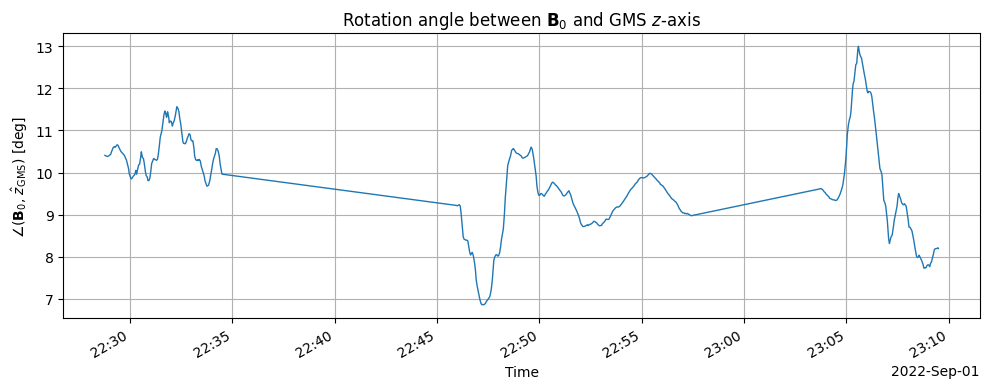

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- R と時刻を連結 -------------------------------------------------
R_all   = np.concatenate([R_dict[f'R_seg{sid}']['R']    for sid in seg_ids])
time_all = np.concatenate([R_dict[f'R_seg{sid}']['time'] for sid in seg_ids])

print(R_all.shape)
print(time_all.shape)

# --- 角度 θ(t) ------------------------------------------------------
e3_z = R_all[:, 2, 2]                       # ẑ·ê₃
angle_deg = np.degrees(
    np.arccos(np.clip(e3_z, -1.0, 1.0))     # 丸め誤差で±1を超えないように
)

# --- プロット -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_all, angle_deg, lw=1)          # ← time_all を使う
ax.set_ylabel(r'∠($\mathbf{B}_0$, $\hat z_{\mathrm{GMS}}$) [deg]')
ax.set_xlabel('Time')
ax.set_title('Rotation angle between $\\mathbf{B}_0$ and GMS $z$‑axis')
ax.grid(True)
fig.autofmt_xdate()                         # 日付ラベルを自動整形
plt.tight_layout()
plt.show()


26-Jul-25 00:52:25: /tmp/ipykernel_1494/116108711.py:38: RuntimeWarning: divide by zero encountered in log10
  axs[1].semilogx(w, 20*np.log10(H_dbl), label='|H(f)| (double-pass)')



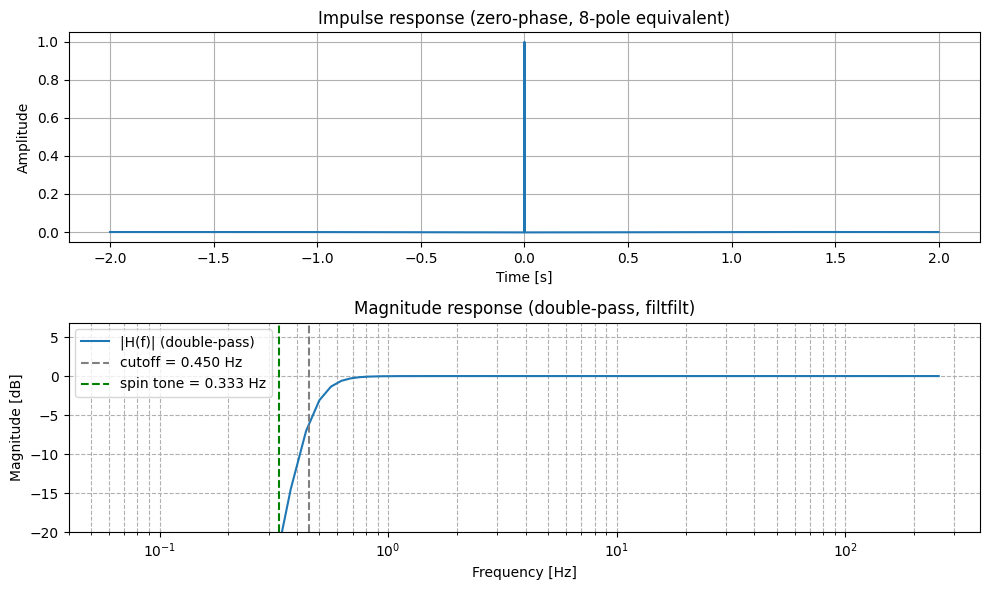

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, sosfreqz

# ------------------ フィルタ設計 ------------------
fs = 512               # サンプリング周波数 [Hz]
cutoff = 0.45            # カットオフ周波数 [Hz]  (spin=8 s → 0.125 Hz より少し高め)
order = 4               # 4次 Butterworth（2-pole × 2-stage）
spin_tone = 1/3         # spin周期 (ERG: 8 sec, THEMIS: 3 sec)

sos = butter(N=order, Wn=cutoff/(fs/2), btype='high', output='sos')

# ------------------ インパルス応答 ------------------
n = 2048                            # インパルス長さ（padlen より十分長く）
delta = np.zeros(n)
delta[n//2] = 1                    # 中央に δ(0)

h = sosfiltfilt(sos, delta)         # 0 相フィルタとして通す
t = (np.arange(n) - n//2) / fs      # 時間軸（0 を中心にシフト）

# ------------------ 周波数応答（片方向１回分） ------------------
w, H = sosfreqz(sos, worN=4096, fs=fs)   # |H(f)| 片方向

# filtfilt は 2 回かけるので、実際の振幅応答は |H(f)|^2 になる
H_dbl = np.abs(H)**2

# ------------------ プロット ------------------
fig, axs = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)

# 時間領域
axs[0].plot(t, h)
axs[0].set_title('Impulse response (zero-phase, 8-pole equivalent)')
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# 周波数領域
axs[1].semilogx(w, 20*np.log10(H_dbl), label='|H(f)| (double-pass)')
axs[1].axvline(cutoff, color='grey', ls='--', label=f'cutoff = {cutoff:.3f} Hz')
axs[1].axvline(spin_tone, color='green', ls='--', label=f'spin tone = {spin_tone:.3f} Hz')
axs[1].set_title('Magnitude response (double-pass, filtfilt)')
axs[1].set_xlabel('Frequency [Hz]')
axs[1].set_ylabel('Magnitude [dB]')
axs[1].set_ylim(-20)
axs[1].set_xlim(4E-2)
#axs[1].set_yscale('symlog', linthresh=1E-1)
axs[1].legend()
axs[1].grid(True, which='both', ls='--')

plt.show()

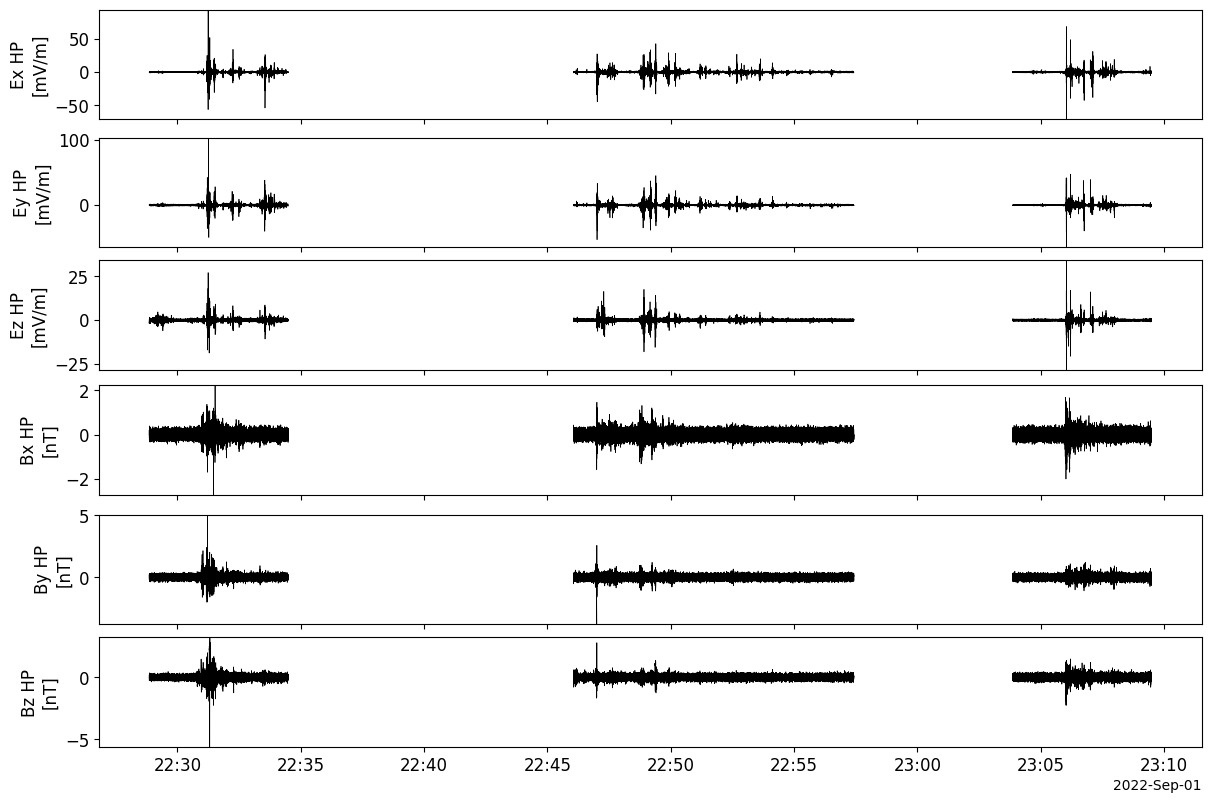

In [9]:
# ------------------------------------------------------------
# 0. Butterworth HPF の係数（質問文と同じ）
# ------------------------------------------------------------
import numpy as np
from scipy.signal import butter, sosfiltfilt
import pytplot as pt

fs, cutoff = 512.0, 0.45
sos = butter(4, cutoff/(fs/2), btype='high', output='sos')

def hp_segmented(y, sos_mat):
    """NaN を含む 1‑D 配列にセグメントごとで sosfiltfilt"""
    good = np.isfinite(y)
    out  = np.full_like(y, np.nan)
    idx  = np.where(good)[0]
    segs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
    padlen = 3 * (sos_mat.shape[0]-1)
    for s in segs:
        if s.size > padlen:
            out[s] = sosfiltfilt(sos_mat, y[s])
    return out

# ------------------------------------------------------------
# 1. セグメント ID を列挙
# ------------------------------------------------------------
seg_ids = sorted({v.split('_seg')[-1] for v in pt.tnames('Ex_fac_seg*')})

# overplot まとめ変数用
Ex_hp, Ey_hp, Ez_hp = [], [], []
Bx_hp, By_hp, Bz_hp = [], [], []

# ------------------------------------------------------------
# 2. 各 seg で HPF → TVar 登録
# ------------------------------------------------------------
for sid in seg_ids:
    for base in ['Ex_fac', 'Ey_fac', 'Ez_fac', 'Bx_fac', 'By_fac', 'Bz_fac']:
        src = f'{base}_seg{sid}'
        da  = pt.data_quants[src]
        hp  = hp_segmented(da.values, sos)

        dst = f'{base}_seg{sid}_hp'
        pt.store_data(dst, data={'x': da.time.values, 'y': hp})

        # 保存しておいて後で overplot 用リストへ
        if   base == 'Ex_fac': Ex_hp.append(dst)
        elif base == 'Ey_fac': Ey_hp.append(dst)
        elif base == 'Ez_fac': Ez_hp.append(dst)
        elif base == 'Bx_fac': Bx_hp.append(dst)
        elif base == 'By_fac': By_hp.append(dst)
        elif base == 'Bz_fac': Bz_hp.append(dst)

        unit = '[mV/m]' if base.startswith('E') else '[nT]'
        pt.options(dst, 'ytitle', base.replace('_fac',' HP'))
        pt.options(dst, 'ysubtitle', unit)

# ------------------------------------------------------------
# 3. まとめ変数を作って overplot
# ------------------------------------------------------------
pt.store_data('Ex_fac_hp_all', data=Ex_hp)
pt.store_data('Ey_fac_hp_all', data=Ey_hp)
pt.store_data('Ez_fac_hp_all', data=Ez_hp)
pt.store_data('Bx_fac_hp_all', data=Bx_hp)
pt.store_data('By_fac_hp_all', data=By_hp)
pt.store_data('Bz_fac_hp_all', data=Bz_hp)

# ------------------------------------------------------------
# 4. 描画（6 パネル）
# ------------------------------------------------------------
pt.tplot(['Ex_fac_hp_all', 'Ey_fac_hp_all', 'Ez_fac_hp_all',
          'Bx_fac_hp_all', 'By_fac_hp_all', 'Bz_fac_hp_all'])


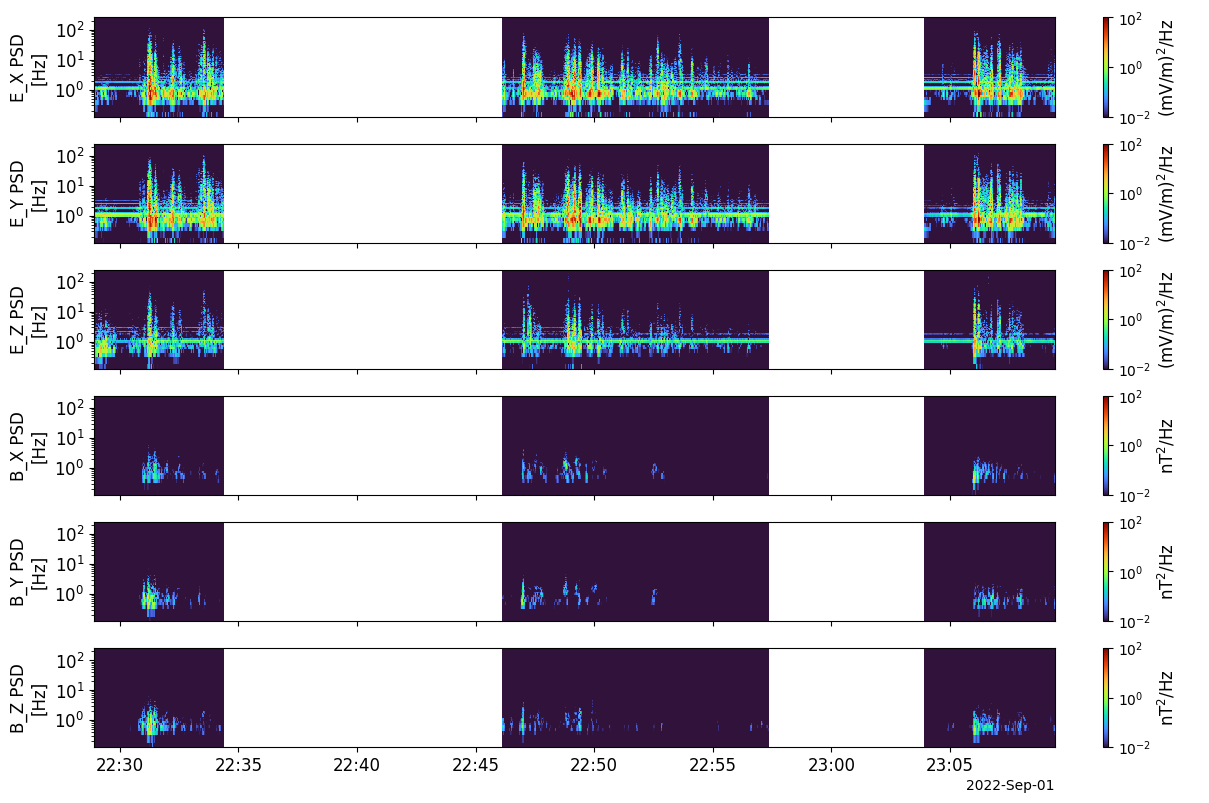

In [10]:
import numpy as np
import pyspedas as psp          # tdpwrspc を呼ぶ
import pytplot as pt

# FFT パラメータ
nbox, nshift = 4096, 4096//8    # ≈8 秒窓を 1 秒刻みでズラすイメージ
bin_size     = 1                # 周波数ビン幅

# まとめ用リスト
Ex_psd, Ey_psd, Ez_psd = [], [], []
Bx_psd, By_psd, Bz_psd = [], [], []

# ── 各セグメントについて処理 ─────────────────────
seg_ids = sorted({v.split('_seg')[-1] for v in pt.tnames('Ex_fac_seg*')})

for sid in seg_ids:
    for EB, unit in [('E', r'(mV/m)$^{2}$/Hz'), ('B', r'nT$^{2}$/Hz')]:
        for comp in ['x', 'y', 'z']:
            src = f'{EB}{comp}_fac_seg{sid}_hp'           # high‑pass 済み
            if src not in pt.data_quants:
                continue

            # PSD 生成（dpwrspc） --------------
            psp.tdpwrspc(src, nboxpoints=nbox,
                              nshiftpoints=nshift,
                              bin=bin_size)               # → src_dpwrspc

            dst = f'{src}_dpwrspc'
            # 軸ラベルなど
            pt.options(dst, 'ylog', 1)
            pt.options(dst, 'zlog', 1)
            pt.options(dst, 'colormap', 'turbo')
            pt.options(dst, 'ztitle', unit)
            pt.options(dst, 'ytitle', f'{EB}_{comp.upper()} PSD')
            pt.options(dst, 'zrange', [1e-2, 1e2])

            # まとめリストに追加
            if   EB == 'E' and comp == 'x': Ex_psd.append(dst)
            elif EB == 'E' and comp == 'y': Ey_psd.append(dst)
            elif EB == 'E' and comp == 'z': Ez_psd.append(dst)
            elif EB == 'B' and comp == 'x': Bx_psd.append(dst)
            elif EB == 'B' and comp == 'y': By_psd.append(dst)
            elif EB == 'B' and comp == 'z': Bz_psd.append(dst)



# ── over‑plot 用リンク変数を作成 ─────────────────
pt.store_data('Ex_psd_all', data=Ex_psd)
pt.store_data('Ey_psd_all', data=Ey_psd)
pt.store_data('Ez_psd_all', data=Ez_psd)
pt.store_data('Bx_psd_all', data=Bx_psd)
pt.store_data('By_psd_all', data=By_psd)
pt.store_data('Bz_psd_all', data=Bz_psd)

for var in ['Ex_psd_all', 'Ey_psd_all', 'Ez_psd_all',
                  'Bx_psd_all', 'By_psd_all', 'Bz_psd_all']:
    pt.options(var, 'ylog', 1)
    pt.options(var, 'zlog', 1)
    pt.options(var, 'colormap', 'turbo')
    pt.options(var, 'ztitle', r'(mV/m)$^{2}$/Hz' if var.startswith('E') else r'nT$^{2}$/Hz')
    pt.options(var, 'zrange', [1e-2, 1e2])  # z軸の範囲を統一

# ── 描画：6 パネルで PSD を一望 ─────────────────
pt.tplot(['Ex_psd_all', 'Ey_psd_all', 'Ez_psd_all',
          'Bx_psd_all', 'By_psd_all', 'Bz_psd_all'])

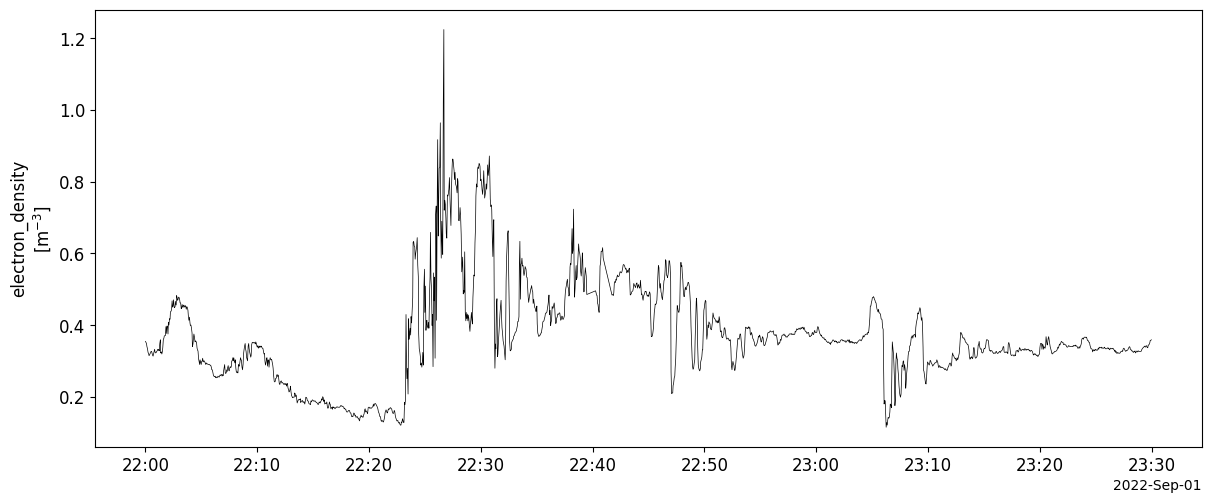

In [11]:
import pandas as pd
import pytplot as pt

file_name_electron_1 = f'{dir_name}/2022-09-01_koseki_a_mom_e_22-23.dat'
file_name_electron_2 = f'{dir_name}/2022-09-01_koseki_a_mom_e_23-24.dat'

df_electron_1 = pd.read_csv(
    file_name_electron_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron_2 = pd.read_csv(
    file_name_electron_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron = pd.concat([df_electron_1, df_electron_2], ignore_index=True)

pt.store_data(
    'electron_density',
    data={'x': df_electron['time'].values, 'y': df_electron['density[cm-3]'].values}
)
pt.options('electron_density', 'ysubtitle', r'$[\mathrm{m}^{-3}]$')

pt.tplot('electron_density')

26-Jul-25 00:53:19: /tmp/ipykernel_1494/1133932378.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_fgm_1 = pd.read_csv(

26-Jul-25 00:53:19: /tmp/ipykernel_1494/1133932378.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_fgm_2 = pd.read_csv(



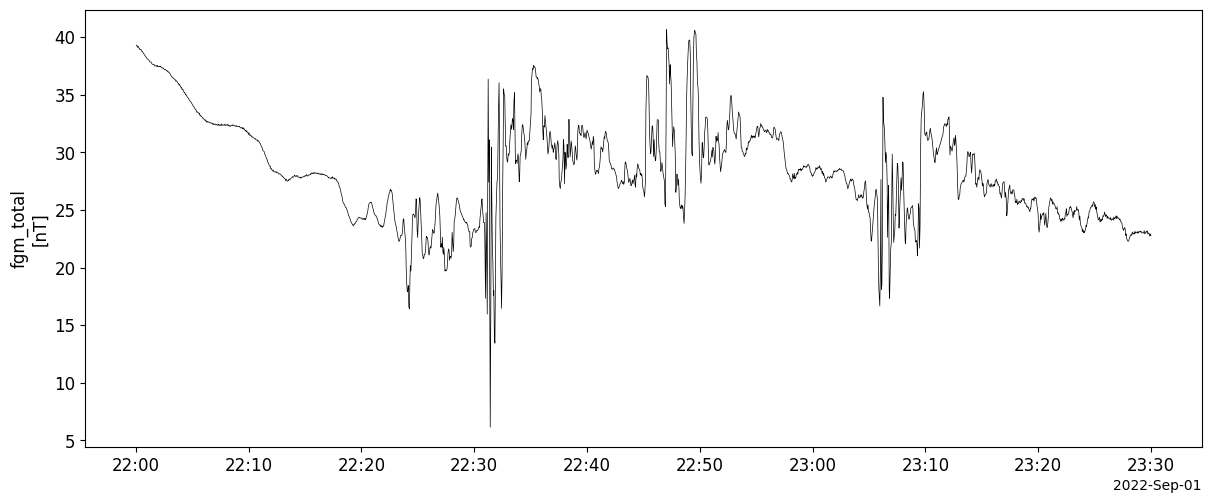

In [12]:
import pandas as pd
import pytplot as pt
import xarray as xr
import numpy as np

file_name_fgm_1 = f'{dir_name}/2022-09-01_koseki_tha_fgm_22-23.dat'
file_name_fgm_2 = f'{dir_name}/2022-09-01_koseki_tha_fgm_23-24.dat'

df_fgm_1 = pd.read_csv(
    file_name_fgm_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm_2 = pd.read_csv(
    file_name_fgm_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm = pd.concat([df_fgm_1, df_fgm_2], ignore_index=True)

df_fgm_gms = df_fgm[['time', 'bx_gms', 'by_gms', 'bz_gms']].copy()
df_fgm_total = xr.Dataset({
    'b_total':
    np.sqrt(df_fgm_gms['bx_gms']**2 +
              df_fgm_gms['by_gms']**2 +
              df_fgm_gms['bz_gms']**2)
    },
    coords={'time': df_fgm_gms['time'].values}
)

pt.store_data(
    'fgm_total',
    data={'x': df_fgm_total['time'].values, 'y': df_fgm_total['b_total'].values}
)
pt.options('fgm_total', 'ytitle', 'fgm_total')
pt.options('fgm_total', 'ysubtitle', '[nT]')
pt.tplot('fgm_total')

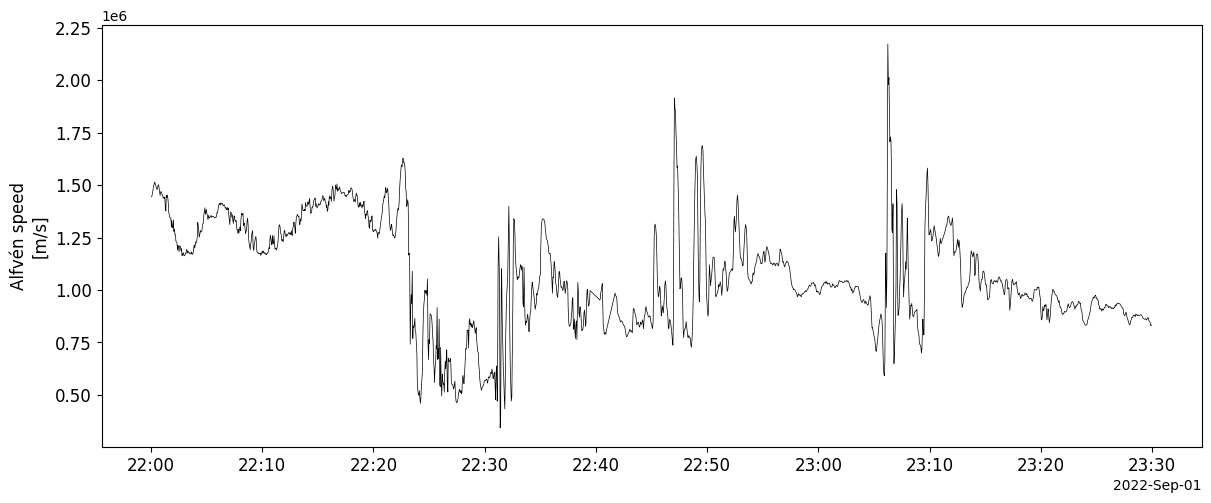

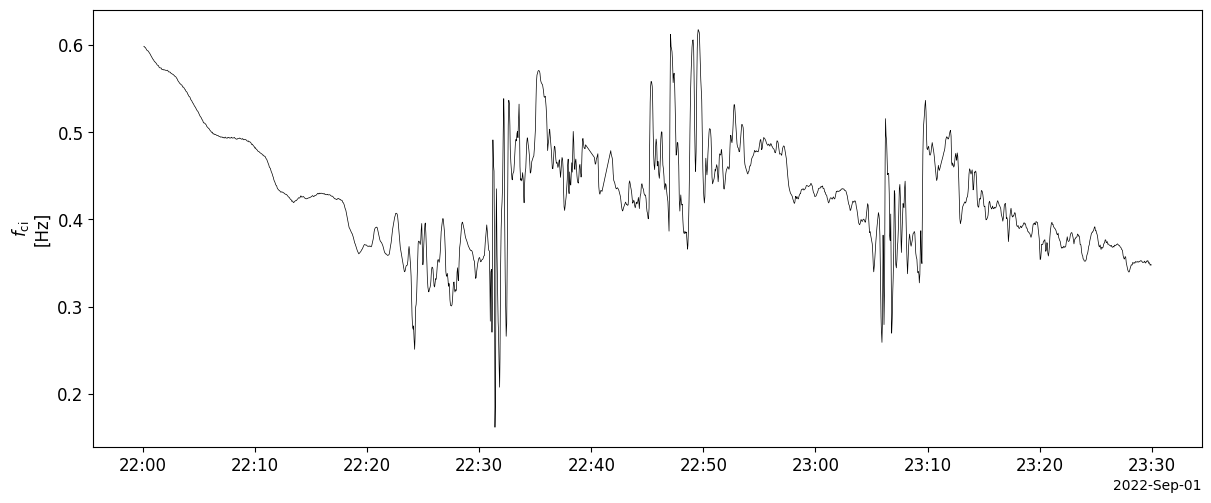

In [13]:
import numpy as np, pytplot as pt, xarray as xr

fgm_total = pt.data_quants['fgm_total']
density = pt.data_quants['electron_density']

density_time = pt.data_quants['electron_density'].time.values

dt_ns = np.median(np.diff(density_time).astype('timedelta64[ns]').astype(float))
dt_sec = dt_ns * 1e-9

fgm_total_interp = fgm_total.interp(time=density_time, method='linear')

mu0 = 4*np.pi*1e-7
mp  = 1.6726219e-27
n_i = density.values * 1e6           # cm⁻³ → m⁻³
proton_mass = 1.6726219e-27  # kg
elementary_charge = 1.60218e-19  # C

v_A = fgm_total_interp * 1e-9 / np.sqrt(mu0 * mp * n_i)  # [m/s]
ion_cycl_freq = elementary_charge * fgm_total_interp * 1E-9 / proton_mass / (2E0 * np.pi)

pt.store_data('Alfven_speed',
              data={'x': density_time, 'y': v_A})
pt.options('Alfven_speed', 'ytitle', 'Alfvén speed')
pt.options('Alfven_speed', 'ysubtitle', '[m/s]')
pt.tplot('Alfven_speed')


pt.store_data('ion_cyclotron_freq',
              data={'x': density_time, 'y': ion_cycl_freq})
pt.options('ion_cyclotron_freq', 'ytitle', r'$f_{\mathrm{ci}}$')
pt.options('ion_cyclotron_freq', 'ysubtitle', '[Hz]')
pt.tplot('ion_cyclotron_freq')

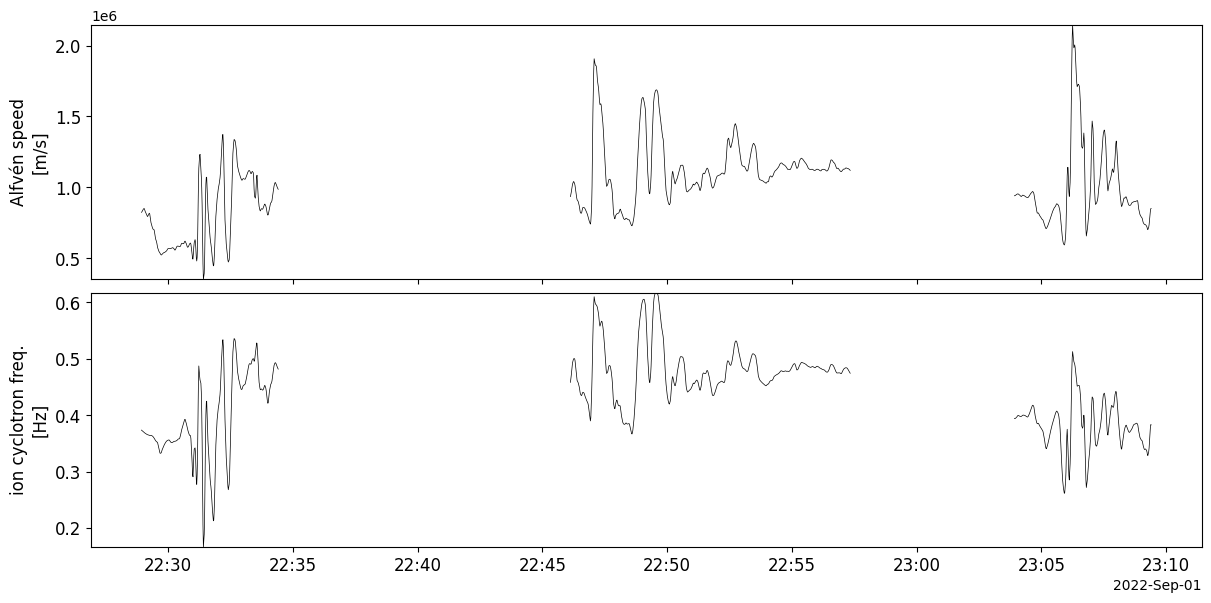

In [14]:
import numpy as np
import pytplot as pt

# ------------------------------------------------------------
# 1. 対象セグメント ID を列挙（手動 or 自動）
# ------------------------------------------------------------
seg_ids = ['0', '1', '2']                 # ここを増減しても OK

# Alfvén 速度 元データ
v_A = pt.data_quants['Alfven_speed']      # xarray.DataArray
ion_cycl_freq = pt.data_quants['ion_cyclotron_freq']

vA_vars, ion_cycl_freq_vars = [], []                              # まとめ用リスト

# ------------------------------------------------------------
# 2. 各セグメントで補間 → TVar 登録
# ------------------------------------------------------------
for sid in seg_ids:
    psd_var = f'Bx_fac_seg{sid}_hp_dpwrspc'
    if psd_var not in pt.data_quants:
        print(f'skip (no {psd_var})')
        continue

    psd_da = pt.data_quants[psd_var]      # PSD DataArray
    t_psd  = psd_da.time.values           # 1‑D datetime64[ns]

    # 線形補間
    vA_interp = v_A.interp(time=t_psd, method='linear')
    ion_cycl_freq_interp = ion_cycl_freq.interp(time=t_psd, method='linear')

    # tplot 変数名
    new_vA = f'vA_seg{sid}_interp'
    vA_vars.append(new_vA)
    new_fci = f'fci_seg{sid}_interp'
    ion_cycl_freq_vars.append(new_fci)

    pt.store_data(new_vA,
                  data={'x': t_psd,
                        'y': vA_interp.values})

    pt.store_data(new_fci,
                  data={'x': t_psd,
                        'y': ion_cycl_freq_interp.values})

    pt.options(new_vA, 'ytitle', 'Alfvén speed')
    pt.options(new_vA, 'ysubtitle', '[m/s]')

    pt.options(new_fci, 'ytitle', 'ion cyclotron freq.')
    pt.options(new_fci, 'ysubtitle', '[Hz]')

# ------------------------------------------------------------
# 3. まとめ変数で over‑plot（一発表示）
# ------------------------------------------------------------
pt.store_data('vA_all_interp', data=vA_vars)
pt.store_data('ion_cycl_freq_all_interp', data=ion_cycl_freq_vars)

pt.tplot(['vA_all_interp', 'ion_cycl_freq_all_interp'])

# flow speedのperpendicular成分を抽出

In [15]:
import pandas as pd
import pytplot as pt

file_name_ion_1 = f'{dir_name}/2022-09-01_koseki_a_mom_i_22-23.dat'
file_name_ion_2 = f'{dir_name}/2022-09-01_koseki_a_mom_i_23-24.dat'

file_name_electron_1 = f'{dir_name}/2022-09-01_koseki_a_mom_e_22-23.dat'
file_name_electron_2 = f'{dir_name}/2022-09-01_koseki_a_mom_e_23-24.dat'

df_ion_1 = pd.read_csv(
    file_name_ion_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_ion_2 = pd.read_csv(
    file_name_ion_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron_1 = pd.read_csv(
    file_name_electron_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron_2 = pd.read_csv(
    file_name_electron_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_ion = pd.concat([df_ion_1, df_ion_2], ignore_index=True)
df_electron = pd.concat([df_electron_1, df_electron_2], ignore_index=True)

# vx[km/s], vy[km/s], vz[km/s] を 抽出
df_ion_velocity_gse = df_electron[['time', 'vx_gse[km/s]', 'vy_gse[km/s]', 'vz_gse[km/s]']].copy()
# temperature_perp1[eV], temperature_perp2[eV], temperature_par[eV] を 抽出
df_ion_temperature = df_ion[['time', 'temperature_perp1[eV]',
                                       'temperature_perp2[eV]', 'temperature_par[eV]']].copy()
df_electron_temperature = df_electron[['time', 'temperature_perp1[eV]',
                                       'temperature_perp2[eV]', 'temperature_par[eV]']].copy()

df_ion_velocity_gse

26-Jul-25 00:53:20: /tmp/ipykernel_1494/3263062245.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_ion_1 = pd.read_csv(

26-Jul-25 00:53:20: /tmp/ipykernel_1494/3263062245.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_ion_2 = pd.read_csv(

26-Jul-25 00:53:20: /tmp/ipykernel_1494/3263062245.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_electron_1 = pd.read_csv(

26-Jul-25 00:53:20: /tmp/ipykernel_1494/3263062245.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_electron_2 = pd.read_csv(



,time,vx_gse[km/s],vy_gse[km/s],vz_gse[km/s]
0,2022-09-01 22:00:01,-6.890132,-35.818337,60.470648
1,2022-09-01 22:00:04,-2.003457,-13.103632,42.870616
2,2022-09-01 22:00:07,16.444587,-8.821231,44.248722
3,2022-09-01 22:00:09,-5.590485,18.210317,51.296339
4,2022-09-01 22:00:12,8.958713,18.453836,53.821812
...,...,...,...,...
1933,2022-09-01 23:29:47,-66.218188,-75.971741,40.443220
1934,2022-09-01 23:29:50,161.861320,-16.728623,25.656249
1935,2022-09-01 23:29:52,66.758285,46.579733,74.814566
1936,2022-09-01 23:29:55,60.981630,63.285002,90.221180


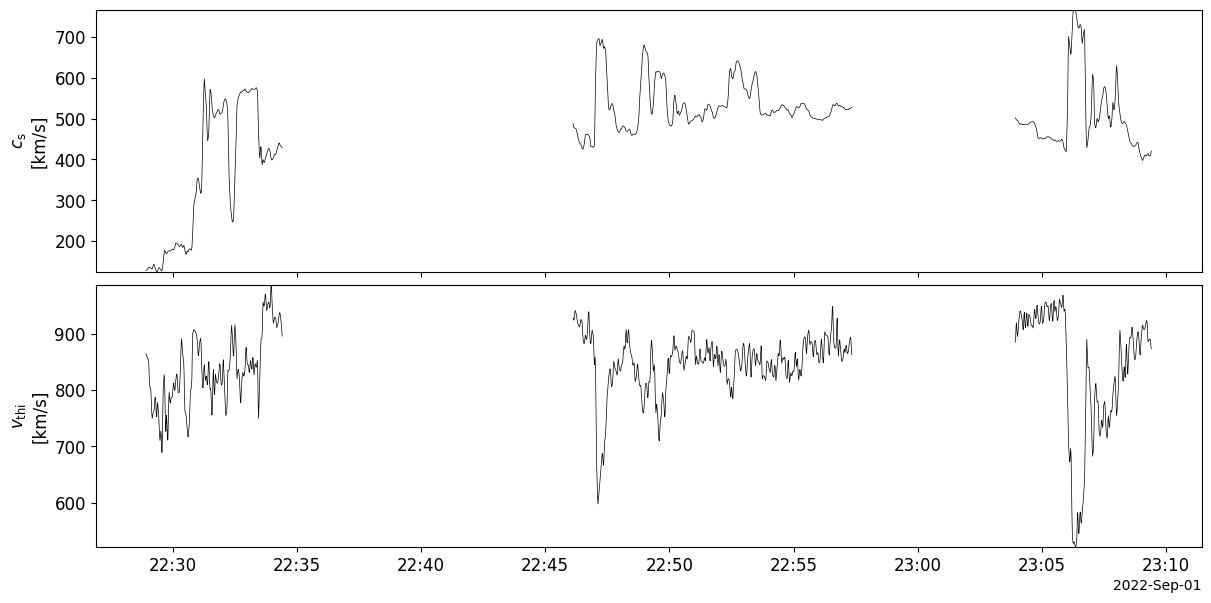

In [16]:
import xarray as xr
import pytplot as pt
import numpy as np

Temp_electron = (df_electron_temperature['temperature_perp1[eV]'] + df_electron_temperature['temperature_perp2[eV]'] + df_electron_temperature['temperature_par[eV]'])/3E0
pt.store_data('Temp_electron', data={'x': df_electron_temperature['time'].values, 'y': Temp_electron.values})

Temp_ion = (df_ion_temperature['temperature_perp1[eV]'] + df_ion_temperature['temperature_perp2[eV]'] + df_ion_temperature['temperature_par[eV]'])/3E0
pt.store_data('Temp_ion', data={'x': df_ion_temperature['time'].values, 'y': Temp_ion.values})

seg_ids = ['0', '1', '2']
ion_acoustic_vel_vars, ion_thermal_vel_vars = [], []

proton_mass = 1.6726219e-27  # kg
elementary_charge = 1.60218e-19  # C

for sid in seg_ids:
    psd_var = f'Bx_fac_seg{sid}_hp_dpwrspc'
    if psd_var not in pt.data_quants:
        print(f'skip (no {psd_var})')
        continue

    psd_da = pt.data_quants[psd_var]      # PSD DataArray
    t_psd  = psd_da.time.values           # 1‑D datetime64[ns]

    # 線形補間
    ion_acoustic_vel_interp = np.sqrt(pt.data_quants['Temp_electron'] * elementary_charge / proton_mass).interp(time=t_psd, method='linear')
    ion_thermal_vel_interp = np.sqrt(2E0 * pt.data_quants['Temp_ion'] * elementary_charge / proton_mass).interp(time=t_psd, method='linear')

    # tplot 変数名
    new_ion_acoustic = f'ion_acoustic_vel_seg{sid}_interp'
    new_ion_thermal = f'ion_thermal_vel_seg{sid}_interp'
    ion_acoustic_vel_vars.append(new_ion_acoustic)
    ion_thermal_vel_vars.append(new_ion_thermal)

    pt.store_data(new_ion_acoustic,
                  data={'x': t_psd,
                        'y': ion_acoustic_vel_interp.values*1E-3})
    
    pt.store_data(
        new_ion_thermal, data={'x': t_psd, 'y': ion_thermal_vel_interp.values*1E-3}
    )

    pt.options(new_ion_acoustic, 'ytitle', r'$c_{\mathrm{s}}$')
    pt.options(new_ion_thermal, 'ytitle', r'$v_{\mathrm{thi}}$')
    pt.options([new_ion_acoustic, new_ion_thermal], 'ysubtitle', '[km/s]')

pt.store_data('ion_acoustic_all_interp', data=ion_acoustic_vel_vars)
pt.store_data('ion_thermal_all_interp', data=ion_thermal_vel_vars)

pt.tplot(['ion_acoustic_all_interp', 'ion_thermal_all_interp'])

26-Jul-25 00:53:22: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:53:22: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:53:22: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:53:22: Substituting symbol \perp from STIXGeneral


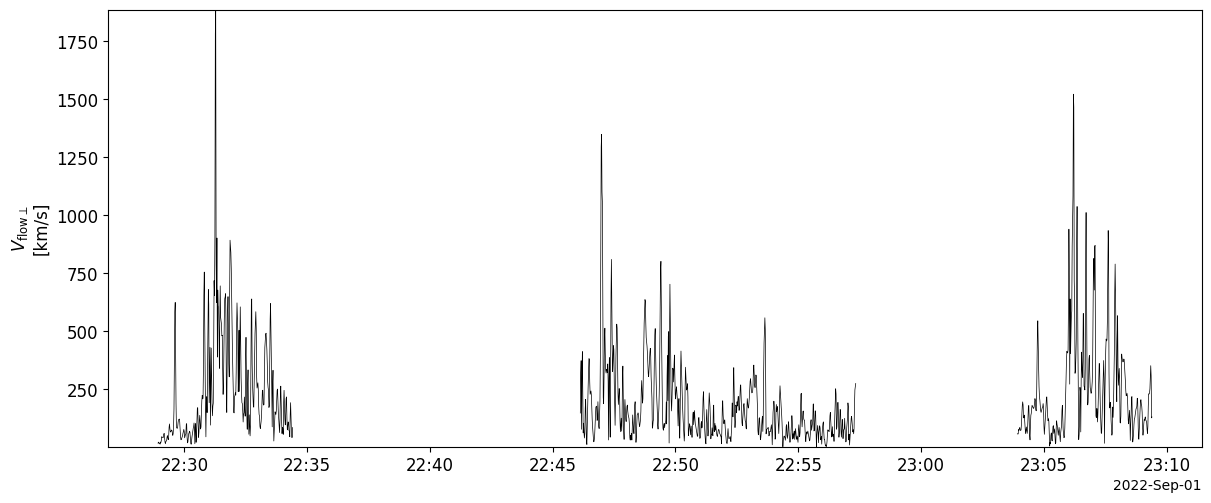

In [17]:
import xarray as xr
import pytplot as pt
import numpy as np

def gse_to_fac(ds: xr.Dataset, ds_lf: xr.Dataset,
               window_sec=100.0) -> tuple[xr.Dataset, xr.DataArray]:
    # ---------- 1. <B> の移動平均 (低周波) ---------------------------
    t_lf   = ds_lf.time.values
    dt     = (t_lf[1]-t_lf[0]).astype('timedelta64[ns]').astype(float)*1e-9
    win    = int(window_sec/dt)

    B_lf   = np.stack([ds_lf[k].values for k in ['bx_gse','by_gse','bz_gse']], axis=1)
    B_avg  = np.vstack([np.nanmean(B_lf[max(i-win//2,0):i+win//2+1], axis=0)
                        for i in range(len(B_lf))])        # (N_lf,3)

    # ---------- 2. FAC 基底 (NumPy) ---------------------------------
    z0 = np.array([0.,0.,1.])
    e2 = np.cross(z0, B_avg)            # (N,3)
    e1 = np.cross(e2, B_avg)
    def _norm(v): return v / np.linalg.norm(v, axis=1, keepdims=True)
    e1h, e2h, e3h = map(_norm, (e1,e2,B_avg))

    R_np = np.stack([e1h, e2h, e3h], axis=2)   # (N_lf,3,3)

    # ---------- 3. DataArray 化して高周波へ補間 -----------------------
    R_da = xr.DataArray(R_np, dims=('time','row','col'),
                        coords={'time': t_lf, 'row':[0,1,2], 'col':[0,1,2]})
    R_hf = R_da.interp(time=ds.time)         # (N_hf,3,3)

    # ---------- 4. B を回して FAC へ --------------------------------
    v_gse = np.stack([ds[k].values for k in ['vx_gse[km/s]', 'vy_gse[km/s]', 'vz_gse[km/s]']], axis=1)
    v_gse_np = np.einsum('tij,tj->ti', R_hf.values, v_gse)  # (N_hf,3)

    # ---------- 5. Dataset に格納 -----------------------------------
    ds_out = xr.Dataset(
        data_vars=dict(
            vx_fac = (('time'), v_gse_np[:,0]),
            vy_fac = (('time'), v_gse_np[:,1]),
            vz_fac = (('time'), v_gse_np[:,2]),
        ),
        coords=dict(time=ds.time)
    )
    return ds_out, R_hf

V_flow_ion_gse_var = ['vx_gse[km/s]', 'vy_gse[km/s]', 'vz_gse[km/s]']
ds_V_flow_ion_gse = xr.Dataset({var:(('time',), df_ion_velocity_gse[var].to_numpy(dtype=float)) for var in V_flow_ion_gse_var}, coords={'time': df_ion_velocity_gse['time'].to_numpy('datetime64[ns]')})

df_fgm_gse = df_fgm[['time', 'bx_gse', 'by_gse', 'bz_gse']].copy()
df_fgm_gse['time'] = df_fgm_gms['time'].astype('datetime64[ns]')

df_fgm_gse

ds_fgm_gse = xr.Dataset({
    'bx_gse': ('time', df_fgm_gse['bx_gse'].to_numpy(dtype=float)),
    'by_gse': ('time', df_fgm_gse['by_gse'].to_numpy(dtype=float)),
    'bz_gse': ('time', df_fgm_gse['bz_gse'].to_numpy(dtype=float))
}, coords={'time': df_fgm_gms['time'].to_numpy('datetime64[ns]')})

ds_V_flow_ion_fac, _ = gse_to_fac(ds_V_flow_ion_gse, ds_fgm_gse)

seg_ids = ['0', '1', '2']

V_flow_ion_vars = []

for sid in seg_ids:
    psd_var = f'Bx_fac_seg{sid}_hp_dpwrspc'
    if psd_var not in pt.data_quants:
        print(f'skip (no {psd_var})')
        continue

    psd_da = pt.data_quants[psd_var]      # PSD DataArray
    t_psd  = psd_da.time.values           # 1‑D datetime64[ns]

    V_flow_ion_fac_interp = ds_V_flow_ion_fac.interp(time=t_psd, method='linear')
    V_flow_perp = np.sqrt((V_flow_ion_fac_interp['vx_fac'].values)**2E0 + (V_flow_ion_fac_interp['vy_fac'].values)**2E0)

    new_V_flow_perp = f'V_flow_perp_seg{sid}_interp'
    V_flow_ion_vars.append(new_V_flow_perp)

    pt.store_data(new_V_flow_perp, data={'x': t_psd, 'y': V_flow_perp})
    pt.options(new_V_flow_perp, 'ytitle', r'$V_{\mathrm{flow}\perp}$')
    pt.options(new_V_flow_perp, 'ysubtitle', '[km/s]')

pt.store_data('V_flow_perp_all_interp', data=V_flow_ion_vars)

pt.tplot('V_flow_perp_all_interp')

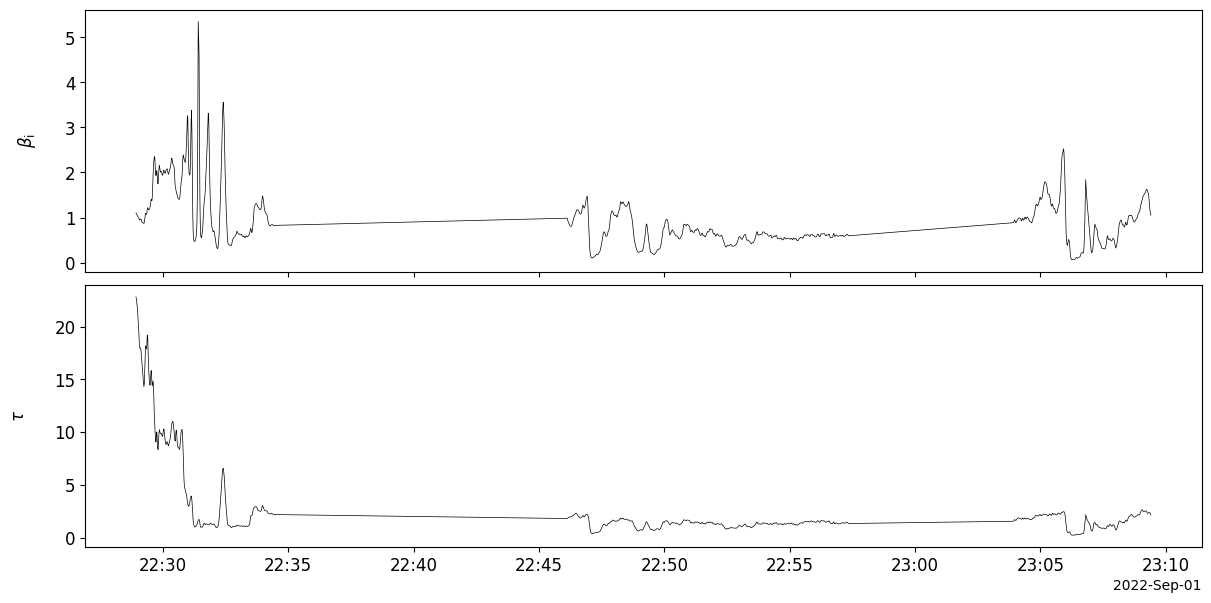

In [18]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt

vA_da  = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('vA_seg*_interp'))],
                   dim='time').sortby('time')

vthi_da  = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_thermal_vel_seg*_interp'))],
                   dim='time').sortby('time')

cs_da = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_acoustic_vel_seg*_interp'))],
                   dim='time').sortby('time')

beta_i = (vthi_da.values / vA_da.values)**2E0
tau = (vthi_da.values / cs_da.values)**2E0 / 2E0

pt.store_data('beta_i', data={'x': vA_da.time.values, 'y': beta_i})
pt.store_data('tau', data={'x': vA_da.time.values, 'y': tau})

pt.options('beta_i', 'ytitle', r'$\beta_{\mathrm{i}}$')
pt.options('tau', 'ytitle', r'$\tau$')

pt.tplot(['beta_i', 'tau'])

# KAW分散関係のplot

<xarray.DataArray 'Ex_fac_seg0_hp_dpwrspc' (time: 1334, v_dim: 2048)> Size: 22MB
array([[4.67323280e-04, 2.63508393e-02, 1.22371764e-01, ...,
        2.03899513e-08, 1.28264512e-07, 1.00155779e-07],
       [2.35326090e-03, 3.24146083e-02, 1.03018868e-01, ...,
        4.81745198e-08, 1.06193635e-07, 1.38026105e-07],
       [7.14415656e-03, 2.75773747e-02, 1.21965812e-01, ...,
        3.94540173e-08, 7.05459582e-08, 1.29423195e-07],
       ...,
       [1.87055604e-03, 6.29923015e-02, 3.34565397e-01, ...,
        5.87355581e-08, 5.37864659e-08, 1.99268784e-09],
       [5.17546896e-04, 6.67979172e-02, 3.67011603e-01, ...,
        1.99705687e-07, 3.69708142e-08, 5.51798885e-10],
       [3.31268539e-03, 5.07640624e-02, 3.89782752e-01, ...,
        3.40013650e-07, 3.80435924e-08, 4.01880018e-10]],
      shape=(1334, 2048))
Coordinates:
  * time       (time) datetime64[ns] 11kB 2022-09-01T22:28:55.403899648 ... 2...
    spec_bins  (time, v_dim) float64 22MB 0.125 0.25 0.375 ... 255.8 255.9 256

26-Jul-25 00:57:52: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:52: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:52: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:52: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:52: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:52: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:53: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:53: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:53: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:53: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:53: Substituting symbol \perp from STIXGeneral
26-Jul-25 00:57:53: Substituting symbol \perp from STIXGeneral


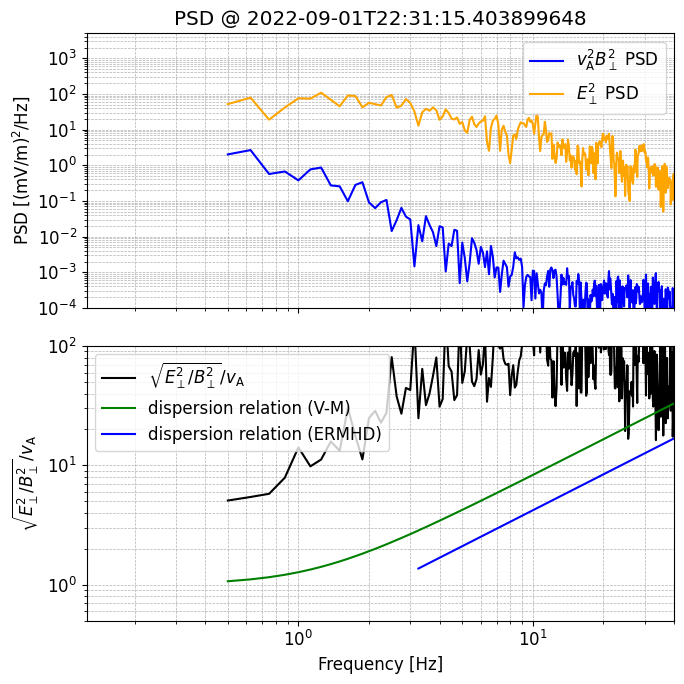

In [19]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()
mpl.rcParams['font.size'] = 12

def seg_list(field: str):
    """
    field = 'Bx' | 'By' | 'Ex' | 'Ey'
    → ['Bx_fac_seg0_i_hp_dpwrspc', 'Bx_fac_seg1_i_hp_dpwrspc', ...]
    """
    return sorted([n for n in pt.data_quants
                   if n.startswith(f'{field}_fac_seg') and
                      n.endswith('_hp_dpwrspc')])

# ------------------------------------------------------------------
# まとめて縦連結する関数
# ------------------------------------------------------------------
def concat_psd(field):
    das = [pt.data_quants[n] for n in seg_list(field)]
    if not das:
        raise ValueError(f'No PSD variables found for {field}')
    return xr.concat(das, dim='time').sortby('time')

Bx_psd = concat_psd('Bx')
By_psd = concat_psd('By')
Ex_psd = concat_psd('Ex')
Ey_psd = concat_psd('Ey')

cutoff = 0.45
mask2d = Bx_psd['spec_bins'] >= cutoff

print(Ex_psd)
print(mask2d)

Bx_psd = Bx_psd.where(mask2d, drop=True)
By_psd = By_psd.where(mask2d, drop=True)
Ex_psd = Ex_psd.where(mask2d, drop=True)
Ey_psd = Ey_psd.where(mask2d, drop=True)

print(Ex_psd)

# v_dim, time の両方で True が 1 つも残らない座標は落ちる
freq   = Bx_psd['v'].values

vA_da  = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('vA_seg*_interp'))],
                   dim='time').sortby('time')

vthi_da  = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('ion_thermal_vel_seg*_interp'))],
                   dim='time').sortby('time')

cs_da = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('ion_acoustic_vel_seg*_interp'))],
                   dim='time').sortby('time')

fci_da = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('fci_seg*_interp'))],
                   dim='time').sortby('time')

Vflowperp_da = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('V_flow_perp_seg*_interp'))],
                   dim='time').sortby('time')

tau_da = pt.data_quants['tau'].interp(time=Bx_psd.time.values, method='linear')
beta_i_da = pt.data_quants['beta_i'].interp(time=Bx_psd.time.values, method='linear')

# ------------------------------------------------------------------
# 任意時刻スライス
# ------------------------------------------------------------------
t0  = np.datetime64('2022-09-01T22:31:15')
idx = np.argmin(np.abs(Bx_psd.time.values - t0))

freq = freq[idx, :]

B_perp2_slice = (Bx_psd[idx] + By_psd[idx]).values * 1e-18          # [T²/Hz]
E_perp2_slice = (Ex_psd[idx] + Ey_psd[idx]).values                  # [(mV/m)²/Hz]

vA_val = vA_da.interp(time=t0).values                               # [m/s]

VA2_B_slice = (vA_val**2) * B_perp2_slice * 1e6                     # [(mV/m)²/Hz]
ratio       = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / vA_val

vA_ = vA_da[idx].values * 1E-3
vthi_ = vthi_da[idx].values
cs_ = cs_da[idx].values
fci_ = fci_da[idx].values
Vflowperp_ = Vflowperp_da[idx].values

E_B_v_A_ratio_VB = (1E0 + (freq / fci_ * vthi_ / Vflowperp_)**2E0) / np.sqrt(1E0 + (freq / fci_)**2E0 * ((cs_ / Vflowperp_)**2E0 + (vthi_ / Vflowperp_)**2E0))

tau = tau_da[idx].values
beta_i = beta_i_da[idx].values

def dispersion_relation_ERMHD(freq):
    """
    すべて ndarray (もしくはブロードキャスト可能な形) を想定。
    戻り値は freq と同じ形の ndarray。
    """
    kperp_rhoi = (freq / fci_ * vthi_ / Vflowperp_)

    # 高k域の式
    high_val = kperp_rhoi * tau / np.sqrt((beta_i * (1.0 + tau) + 2.0 * tau) * (1.0 + tau))

    # 条件ごとの値を np.select で選ぶ
    conds    = [kperp_rhoi < np.sqrt(0.1),
                kperp_rhoi > np.sqrt(10.0)]
    choices  = [np.ones_like(kperp_rhoi), high_val]
    result   = np.select(conds, choices, default=np.nan)

    return result

E_B_v_A_ratio_ERMHD = dispersion_relation_ERMHD(freq)

# ------------------------------------------------------------------
# プロット
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})

# --- (a) 既存の v_A2B⊥2 と E⊥2 -----------------------------------
ax1.loglog(freq, VA2_B_slice, label=r'$v_\mathrm{A}^{2}B_\perp^{2}$ PSD', color='b')
ax1.loglog(freq, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD', color='orange')
ax1.set_ylabel(r'PSD [$(\mathrm{mV/m})^{2}$/Hz]')
ax1.set_title(f'PSD @ {np.datetime_as_string(Bx_psd.time.values[idx], unit="ns")}')
ax1.grid(True, which='both', ls='--', lw=0.5)
ax1.set_ylim(1e-4, 5e3)
ax1.set_xlim(1/8, 4e1)
ax1.legend()

# --- (b) 無次元比 √(E⊥2/B⊥2)/v_A -----------------------------------
ax2.loglog(freq, ratio, color='k', label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
ax2.loglog(freq, E_B_v_A_ratio_VB, color='green', label=r'dispersion relation (V-M)')
ax2.loglog(freq, E_B_v_A_ratio_ERMHD, color='blue', label=r'dispersion relation (ERMHD)')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
ax2.grid(True, which='both', ls='--', lw=0.5)
ax2.set_ylim(5E-1, 1E2)
ax2.legend()

plt.tight_layout()
plt.show()

In [76]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()

# ------------------------------------------------------------
# 0.  util: seg をまとめて縦連結する関数
# ------------------------------------------------------------
def concat_psd(field: str) -> xr.DataArray:
    """
    field : 'Bx' | 'By' | 'Ex' | 'Ey'
    TVar 名が  <field>_fac_seg<i>_i_hp_dpwrspc  という規則で登録されている前提。
    それらを time 軸で連結して返す。
    """
    names = sorted(n for n in pt.data_quants
                   if n.startswith(f'{field}_fac_seg') and
                      n.endswith('_hp_dpwrspc'))
    if not names:
        raise ValueError(f'No PSD variables found for {field}')
    return xr.concat([pt.data_quants[n] for n in names], dim='time').sortby('time')

# ------------------------------------------------------------
# 1. PSD と Alfvén 速度を結合（seg0‑2 を一本化）
# ------------------------------------------------------------
Bx_psd = concat_psd('Bx')
By_psd = concat_psd('By')
Ex_psd = concat_psd('Ex')
Ey_psd = concat_psd('Ey')

cutoff = 0.45
mask2d = Bx_psd['spec_bins'] >= cutoff

Bx_psd = Bx_psd.where(mask2d, drop=True)
By_psd = By_psd.where(mask2d, drop=True)
Ex_psd = Ex_psd.where(mask2d, drop=True)
Ey_psd = Ey_psd.where(mask2d, drop=True)

freq   = Bx_psd['v'].values

# Alfvén 速度も seg ごとに結合しておく
vA_da  = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('vA_seg*_interp'))],
                   dim='time').sortby('time')

vthi_da  = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_thermal_vel_seg*_interp'))],
                   dim='time').sortby('time')

cs_da = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_acoustic_vel_seg*_interp'))],
                   dim='time').sortby('time')

fci_da = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('fci_seg*_interp'))],
                   dim='time').sortby('time')

Vflowperp_da = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('V_flow_perp_seg*_interp'))],
                   dim='time').sortby('time')

tau_da = pt.data_quants['tau'].interp(time=Bx_psd.time.values, method='linear')
beta_i_da = pt.data_quants['beta_i'].interp(time=Bx_psd.time.values, method='linear')

# ------------------------------------------------------------
# 2. 出力フォルダと対象時間帯
# ------------------------------------------------------------
out_dir = '/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01/22-24_dprt'
os.makedirs(out_dir, exist_ok=True)

t_min = np.datetime64('2022-09-01T22:30:00')
t_max = np.datetime64('2022-09-01T23:30:00')

# ------------------------------------------------------------
# 3. ループしてスナップショット作成
# ------------------------------------------------------------

def dispersion_relation_ERMHD(freq, fci_, vthi_, Vflowperp_, beta_i, tau):
    """
    すべて ndarray (もしくはブロードキャスト可能な形) を想定。
    戻り値は freq と同じ形の ndarray。
    """
    kperp_rhoi = (freq / fci_ * vthi_ / Vflowperp_)

    # 高k域の式
    high_val = kperp_rhoi * tau / np.sqrt((beta_i * (1.0 + tau) + 2.0 * tau) * (1.0 + tau))

    # 条件ごとの値を np.select で選ぶ
    conds    = [kperp_rhoi < np.sqrt(0.1),
                kperp_rhoi > np.sqrt(10.0)]
    choices  = [np.ones_like(kperp_rhoi), high_val]
    result   = np.select(conds, choices, default=np.nan)

    return result

for idx, t in enumerate(Bx_psd.time.values):
    if not (t_min <= t <= t_max):
        continue

    freq_ = freq[idx, :]

    # --- PSD スライス --------------------------------------------------
    B_perp2_slice = (Bx_psd[idx] + By_psd[idx]).values * 1e-18     # [T²/Hz]
    E_perp2_slice = (Ex_psd[idx] + Ey_psd[idx]).values             # [(mV/m)²/Hz]

    vA_val = float(vA_da.interp(time=t))                           # [m/s]

    VA2_B_slice = (vA_val**2) * B_perp2_slice * 1e6                # [(mV/m)²/Hz]
    ratio       = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / vA_val

    vA_ = vA_da[idx].values
    vthi_ = vthi_da[idx].values
    cs_ = cs_da[idx].values
    fci_ = fci_da[idx].values
    Vflowperp_ = Vflowperp_da[idx].values
    beta_i_ = beta_i_da[idx].values
    tau_ = tau_da[idx].values

    E_B_v_A_ratio_VB = (1E0 + (freq_ / fci_ * vthi_ / Vflowperp_)**2E0) / np.sqrt(1E0 + (freq_ / fci_)**2E0 * ((cs_ / Vflowperp_)**2E0 + (vthi_ / Vflowperp_)**2E0))

    E_B_v_A_ratio_ERMHD = dispersion_relation_ERMHD(freq_, fci_, vthi_, Vflowperp_, beta_i_, tau_)

    # --- プロット ------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                   gridspec_kw={'height_ratios': [1, 1]})

    ax1.loglog(freq_, VA2_B_slice, label=r'$v_\mathrm{A}^{2}B_\perp^{2}$ PSD', color='b')
    ax1.loglog(freq_, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD', color='orange')
    ax1.set_ylabel(r'PSD [$(\mathrm{mV/m})^{2}$/Hz]')
    ax1.set_title(f'PSD @ {np.datetime_as_string(Bx_psd.time.values[idx], unit="ns")}')
    ax1.grid(True, which='both', ls='--', lw=0.5)
    ax1.set_ylim(1e-6, 5e1)
    ax1.set_xlim(1/3, 4e1)
    ax1.legend()

    ax2.loglog(freq_, ratio, color='k', label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
    ax2.loglog(freq_, E_B_v_A_ratio_VB, color='green', label=r'dispersion relation (V-M)')
    ax2.loglog(freq_, E_B_v_A_ratio_ERMHD, color='blue', label=r'dispersion relation (ERMHD)')
    ax2.set_xlabel('Frequency [Hz]')
    ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
    ax2.grid(True, which='both', ls='--', lw=0.5)
    ax2.set_ylim(5E-1, 1E2)
    ax2.legend()

    plt.tight_layout()

    # --- 保存 ----------------------------------------------------------
    fname = f'{np.datetime_as_string(t, unit="ns")}.png'
    fig.savefig(os.path.join(out_dir, fname), dpi=200)
    plt.close(fig)

print('Finished saving all plots!')


26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:02: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:03: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:03: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:03: Substituting symbol \perp from STIXGeneral
26-Jul-25 02:32:03: Substituting symbol \perp from STIX

Finished saving all plots!


In [ ]:
import os
from natsort import natsorted
import imageio                # ← v3 なら imageio.v2 を付けなくても同じ

img_dir = '/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01/22-24'
png_files = natsorted([os.path.join(img_dir, f)
                       for f in os.listdir(img_dir)
                       if f.lower().endswith('.png')])

frames = [imageio.imread(f) for f in png_files]
out_path = os.path.join(img_dir, 'E_B_ratio_ERG.mp4')

# codec は imageio-ffmpeg の同梱バイナリが自動で使われる
imageio.mimsave(out_path, frames, fps=5, codec='libx264')
print('saved to', out_path)

21-Jul-25 17:49:50: /tmp/ipykernel_4416/3429315788.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in png_files]

21-Jul-25 17:50:33: IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1400) to (1408, 1408) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


saved to /mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01/22-24/E_B_ratio_ERG.mp4


: 

In [74]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()

# ------------------------------------------------------------
# 0.  util: seg をまとめて縦連結する関数
# ------------------------------------------------------------
def concat_psd(field: str) -> xr.DataArray:
    """
    field : 'Bx' | 'By' | 'Ex' | 'Ey'
    TVar 名が  <field>_fac_seg<i>_i_hp_dpwrspc  という規則で登録されている前提。
    それらを time 軸で連結して返す。
    """
    names = sorted(n for n in pt.data_quants
                   if n.startswith(f'{field}_fac_seg') and
                      n.endswith('_hp_dpwrspc'))
    if not names:
        raise ValueError(f'No PSD variables found for {field}')
    return xr.concat([pt.data_quants[n] for n in names], dim='time').sortby('time')

# ------------------------------------------------------------
# 1. PSD と Alfvén 速度を結合（seg0‑2 を一本化）
# ------------------------------------------------------------
Bx_psd = concat_psd('Bx')
By_psd = concat_psd('By')
Ex_psd = concat_psd('Ex')
Ey_psd = concat_psd('Ey')

cutoff = 0.45
mask2d = Bx_psd['spec_bins'] >= cutoff

Bx_psd = Bx_psd.where(mask2d, drop=True)
By_psd = By_psd.where(mask2d, drop=True)
Ex_psd = Ex_psd.where(mask2d, drop=True)
Ey_psd = Ey_psd.where(mask2d, drop=True)

freq   = Bx_psd['v'].values

# Alfvén 速度も seg ごとに結合しておく
vA_da  = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('vA_seg*_interp'))],
                   dim='time').sortby('time')

vthi_da  = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_thermal_vel_seg*_interp'))],
                   dim='time').sortby('time')

cs_da = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_acoustic_vel_seg*_interp'))],
                   dim='time').sortby('time')

fci_da = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('fci_seg*_interp'))],
                   dim='time').sortby('time')

Vflowperp_da = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('V_flow_perp_seg*_interp'))],
                   dim='time').sortby('time')

tau_da = pt.data_quants['tau'].interp(time=Bx_psd.time.values, method='linear')
beta_i_da = pt.data_quants['beta_i'].interp(time=Bx_psd.time.values, method='linear')

# ------------------------------------------------------------
# 2. 出力フォルダと対象時間帯
# ------------------------------------------------------------
out_dir = '/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01/22-24_dprt_kperprhoi'
os.makedirs(out_dir, exist_ok=True)

t_min = np.datetime64('2022-09-01T22:30:00')
t_max = np.datetime64('2022-09-01T23:30:00')

# ------------------------------------------------------------
# 3. ループしてスナップショット作成
# ------------------------------------------------------------

def dispersion_relation_ERMHD(kperp_rhoi, fci_, vthi_, Vflowperp_, beta_i, tau):
    """
    すべて ndarray (もしくはブロードキャスト可能な形) を想定。
    戻り値は freq と同じ形の ndarray。
    """

    # 高k域の式
    high_val = kperp_rhoi * tau / np.sqrt((beta_i * (1.0 + tau) + 2.0 * tau) * (1.0 + tau))

    # 条件ごとの値を np.select で選ぶ
    conds    = [kperp_rhoi < np.sqrt(0.1),
                kperp_rhoi > np.sqrt(10.0)]
    choices  = [np.ones_like(kperp_rhoi), high_val]
    result   = np.select(conds, choices, default=np.nan)

    return result

for idx, t in enumerate(Bx_psd.time.values):
    if not (t_min <= t <= t_max):
        continue

    # --- PSD スライス --------------------------------------------------
    B_perp2_slice = (Bx_psd[idx] + By_psd[idx]).values * 1e-18     # [T²/Hz]
    E_perp2_slice = (Ex_psd[idx] + Ey_psd[idx]).values             # [(mV/m)²/Hz]

    freq_ = freq[idx, :]

    vA_val = float(vA_da.interp(time=t))                           # [m/s]

    VA2_B_slice = (vA_val**2) * B_perp2_slice * 1e6                # [(mV/m)²/Hz]
    ratio       = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / vA_val

    vA_ = vA_da[idx].values
    vthi_ = vthi_da[idx].values
    cs_ = cs_da[idx].values
    fci_ = fci_da[idx].values
    Vflowperp_ = Vflowperp_da[idx].values
    beta_i_ = beta_i_da[idx].values
    tau_ = tau_da[idx].values

    kperp_rhoi_ob = freq_ / fci_ * vthi_ / Vflowperp_

    kperp_rhoi_th = np.logspace(-1, 2, 10000)

    E_B_v_A_ratio_VB = (1E0 + kperp_rhoi_th**2E0) / np.sqrt(1E0 + kperp_rhoi_th**2E0 * (1E0 + (cs_ / vthi_)**2E0))

    E_B_v_A_ratio_ERMHD = dispersion_relation_ERMHD(kperp_rhoi_th, fci_, vthi_, Vflowperp_, beta_i_, tau_)

    # --- プロット ------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                   gridspec_kw={'height_ratios': [1, 1]})

    ax1.loglog(kperp_rhoi_ob, VA2_B_slice, label=r'$v_\mathrm{A}^{2}B_\perp^{2}$ PSD', color='b')
    ax1.loglog(kperp_rhoi_ob, E_perp2_slice,    label=r'$E_\perp^{2}$ PSD', color='orange')
    ax1.set_ylabel(r'PSD [$(\mathrm{mV/m})^{2}$/Hz]')
    ax1.set_title(f'PSD @ {np.datetime_as_string(Bx_psd.time.values[idx], unit="ns")}')
    ax1.grid(True, which='both', ls='--', lw=0.5)
    ax1.set_ylim(1e-6, 5e1)
    ax1.set_xlim(1e-1, 1e2)
    ax1.legend()

    ax2.loglog(kperp_rhoi_ob, ratio, color='k', label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
    ax2.loglog(kperp_rhoi_th, E_B_v_A_ratio_VB, color='green', label=r'dispersion relation (V-M)')
    ax2.loglog(kperp_rhoi_th, E_B_v_A_ratio_ERMHD, color='blue', label=r'dispersion relation (ERMHD)')
    ax2.set_xlabel('Frequency [Hz]')
    ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_{\mathrm{A}}$')
    ax2.grid(True, which='both', ls='--', lw=0.5)
    ax2.set_ylim(5e-1, 1e2)
    ax2.set_xlim(1e-1, 1e2)
    ax2.legend()

    plt.tight_layout()

    # --- 保存 ----------------------------------------------------------
    fname = f'{np.datetime_as_string(t, unit="ns")}.png'
    fig.savefig(os.path.join(out_dir, fname), dpi=200)
    plt.close(fig)

print('Finished saving all plots!')

26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:26: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:27: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:27: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:27: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:26:27: Substituting symbol \perp from STIX

Finished saving all plots!


# パワースペクトルの時間平均を取る

26-Jul-25 01:16:22: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,



[]


26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIXGeneral
26-Jul-25 01:16:23: Substituting symbol \perp from STIX

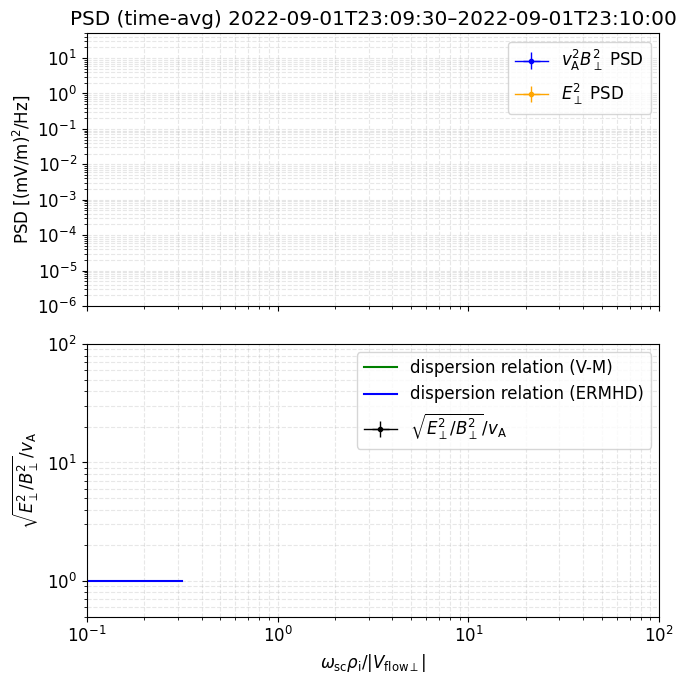

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl
import xarray as xr
from scipy.stats import chi2, linregress, t

# -----------------------------------------------------------
# 0. matplotlib 設定
# -----------------------------------------------------------
mpl.rcdefaults()
mpl.rcParams['font.size'] = 12

# -----------------------------------------------------------
# 1. もとの DataArray を取得
# -----------------------------------------------------------

def concat_psd(field: str) -> xr.DataArray:
    """
    field : 'Bx' | 'By' | 'Ex' | 'Ey'
    TVar 名が  <field>_fac_seg<i>_i_hp_dpwrspc  という規則で登録されている前提。
    それらを time 軸で連結して返す。
    """
    names = sorted(n for n in pt.data_quants
                   if n.startswith(f'{field}_fac_seg') and
                      n.endswith('_hp_dpwrspc'))
    if not names:
        raise ValueError(f'No PSD variables found for {field}')
    return xr.concat([pt.data_quants[n] for n in names], dim='time').sortby('time')

Bx_psd = concat_psd('Bx')
By_psd = concat_psd('By')
Ex_psd = concat_psd('Ex')
Ey_psd = concat_psd('Ey')

cutoff = 0.45
mask2d = Bx_psd['spec_bins'] >= cutoff

Bx_psd = Bx_psd.where(mask2d, drop=True)
By_psd = By_psd.where(mask2d, drop=True)
Ex_psd = Ex_psd.where(mask2d, drop=True)
Ey_psd = Ey_psd.where(mask2d, drop=True)

freq   = Bx_psd['v'].values

# B/E の時間軸を一致させる（グリッドが微妙に違う可能性がある）
#Ex_psd = Ex_psd.interp(time=Bx_psd.time, method='linear')
#Ey_psd = Ey_psd.interp(time=Bx_psd.time, method='linear')

time_new = Bx_psd.time.values  # 以後この time 軸を基準にする

# -----------------------------------------------------------
# 2. 必要物理量を同じ時間軸へ補間
# -----------------------------------------------------------
vA_da  = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('vA_seg*_interp'))],
                   dim='time').sortby('time')

vthi_da  = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_thermal_vel_seg*_interp'))],
                   dim='time').sortby('time')

cs_da = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('ion_acoustic_vel_seg*_interp'))],
                   dim='time').sortby('time')

fci_da = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('fci_seg*_interp'))],
                   dim='time').sortby('time')

Vflowperp_da = xr.concat([pt.data_quants[n] * 1E3
                    for n in sorted(pt.tnames('V_flow_perp_seg*_interp'))],
                   dim='time').sortby('time')

tau_da = pt.data_quants['tau'].interp(time=Bx_psd.time.values, method='linear')
beta_i_da = pt.data_quants['beta_i'].interp(time=Bx_psd.time.values, method='linear')


# -----------------------------------------------------------
# 3. k_perp * rho_i 軸（観測値）を計算
#    kperp_rhoi_ob = (ω_sc / ω_ci) * (V_th / |V_flow⊥|)
# -----------------------------------------------------------
f      = freq[0, :]            # (nfreq)
w_ci   = fci_da.values
vth_i  = vthi_da.values
vperp  = Vflowperp_da.values

kperp_rhoi_ob = (f[None, :] / w_ci[:, None]) * (vth_i[:, None] / vperp[:, None])  # (time, freq)

# -----------------------------------------------------------
# 4. PSD 計算： v_A^2 B_perp^2 と E_perp^2
# -----------------------------------------------------------
vA2        = (vA_da.interp(time=time_new, method='linear').values**2)[:, None]  # (time,1)
VA2_Bperp2 = vA2 * (Bx_psd.values + By_psd.values) * 1e-12  # [(mV/m)^2/Hz]
E_perp2    = (Ex_psd.values + Ey_psd.values)                # [(mV/m)^2/Hz]

# -----------------------------------------------------------
# 5. 対象時間範囲を指定＆切り出し
# -----------------------------------------------------------
t0 = np.datetime64('2022-09-01T23:04:00') + np.timedelta64(30, 's') * 11

t1 = t0 + np.timedelta64(30, 's')
#t1 = np.datetime64('2022-09-01T22:31:30')

# DataArray にすることで .sel が楽
k_da   = xr.DataArray(kperp_rhoi_ob, coords={'time': time_new, 'freq': f}, dims=('time', 'freq'))
va2_da = xr.DataArray(VA2_Bperp2,    coords={'time': time_new, 'freq': f}, dims=('time', 'freq'))
e_da   = xr.DataArray(E_perp2,       coords={'time': time_new, 'freq': f}, dims=('time', 'freq'))

k_sel   = k_da.sel(time=slice(t0, t1)).values
VA2_sel = va2_da.sel(time=slice(t0, t1)).values
E_sel   = e_da.sel(time=slice(t0, t1)).values

print(E_sel)

# tau, beta_i, r = C_s/V_th も同じ時間窓で切り出し
idx_t   = (time_new >= t0) & (time_new <= t1)
tau_sel = tau_da.values[idx_t]
beta_sel= beta_i_da.values[idx_t]
r_sel   = (cs_da.values / Vflowperp_da.values)[idx_t]

# -----------------------------------------------------------
# 6. ログ等間隔の k⊥ρ_i グリッドを用意してビン詰め
#    → ビンごとに幾何平均と非対称エラーバー
# -----------------------------------------------------------
kmin, kmax = 1e-1, 1e2
nbin = 15
bin_edges   = np.logspace(np.log10(kmin), np.log10(kmax), nbin + 1)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # 幾何平均中心
xerr        = np.vstack([bin_centers - bin_edges[:-1], bin_edges[1:] - bin_centers])

def bin_fill(k_mat, y_mat, edges):
    """
    k_mat: (time, freq) の k_perp*rho_i
    y_mat: 同次元の PSD 等
    edges: bin_edges (1D)
    return: list of arrays in each bin
    """
    nb = len(edges) - 1
    res = [[] for _ in range(nb)]
    for k_row, y_row in zip(k_mat, y_mat):
        good = np.isfinite(k_row) & np.isfinite(y_row) & (k_row > 0)
        if not np.any(good):
            continue
        bidx = np.digitize(k_row[good], edges) - 1
        in_range = (bidx >= 0) & (bidx < nb)
        for y_i, bi in zip(y_row[good][in_range], bidx[in_range]):
            res[bi].append(y_i)
    return res

vals_VA2_bins = bin_fill(k_sel, VA2_sel, bin_edges)
vals_E_bins   = bin_fill(k_sel, E_sel,   bin_edges)

# PSD比 R = sqrt(E_perp^2 / (v_A^2 B_perp^2)) も同様にビン詰め
vals_R_bins = bin_fill(k_sel, np.sqrt(E_sel / VA2_sel), bin_edges)

# -----------------------------------------------------------
# 7. 幾何平均 + 非対称エラーバー（ログ空間分位点 or SEM など）
# -----------------------------------------------------------
def geom_stats(values, mode='quantile', alpha=0.32):
    """
    values : list/array (>0) のデータ
    mode   : 'sem' | 'sd' | 'quantile' | 'chi2'
    alpha  : 信頼区間幅 (0.32 → 68%区間)
    戻り値 : (geom_mean, err_low, err_high) すべて線形空間
    """
    arr = np.asarray(values, float)
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if arr.size == 0:
        return np.nan, np.nan, np.nan

    if mode == 'chi2':
        mean_lin = np.mean(arr)
        M = arr.size  # 本来は独立セグメント数
        lower = mean_lin * (2*M) / chi2.ppf(1 - alpha/2, 2*M)
        upper = mean_lin * (2*M) / chi2.ppf(alpha/2,     2*M)
        return mean_lin, mean_lin - lower, upper - mean_lin

    # ここから幾何平均系
    logp = np.log10(arr)
    mu   = logp.mean()
    if mode == 'sem':
        se = logp.std(ddof=1) / np.sqrt(logp.size)
        lo, hi = mu - se, mu + se
    elif mode == 'sd':
        sd = logp.std(ddof=1)
        lo, hi = mu - sd, mu + sd
    elif mode == 'quantile':
        qlo, qhi = np.nanpercentile(logp, [100*alpha/2, 100*(1-alpha/2)])
        lo, hi = qlo, qhi
    else:
        raise ValueError("mode must be one of 'sem','sd','quantile','chi2'.")

    gm = 10**mu
    err_lo = gm - 10**lo
    err_hi = 10**hi - gm
    return gm, err_lo, err_hi

def stats_bins(list_of_lists, mode='quantile', alpha=0.32):
    gm, lo, hi = [], [], []
    for vals in list_of_lists:
        m, l, h = geom_stats(vals, mode=mode, alpha=alpha)
        gm.append(m); lo.append(l); hi.append(h)
    return np.array(gm), np.vstack([lo, hi])

gm_VA2, yerr_VA2 = stats_bins(vals_VA2_bins, mode='quantile', alpha=0.32)
gm_E,   yerr_E   = stats_bins(vals_E_bins,   mode='quantile', alpha=0.32)
gm_R,   yerr_R   = stats_bins(vals_R_bins,   mode='quantile', alpha=0.32)

# -----------------------------------------------------------
# 8. 理論分散関係 (V-M, ERMHD) とそのエラーバンド
# -----------------------------------------------------------
# 8.1 時間窓で tau/beta/r の幾何平均＆CIを計算
gm_tau,  lo_tau,  hi_tau  = geom_stats(tau_sel,  mode='quantile', alpha=0.32)
gm_beta, lo_beta, hi_beta = geom_stats(beta_sel, mode='quantile', alpha=0.32)
gm_r,    lo_r,    hi_r    = geom_stats(r_sel,    mode='quantile', alpha=0.32)

# 8.2 理論用 kグリッド
k_th  = np.logspace(-1, 2, 1000)
k_th1 = np.logspace(-1, np.log10(np.sqrt(0.1)), 300)  # ERMHD 定数域
k_th4 = np.logspace(np.log10(np.sqrt(10)), 2, 300)    # ERMHD ∝k域

# 8.3 中心値での理論曲線
E_B_v_A_ratio_VB_c    = (1.0 + k_th**2) / np.sqrt(1.0 + k_th**2 * (1.0 + gm_r**2))
E_B_v_A_ratio_ERMHD_c1= np.ones_like(k_th1)
E_B_v_A_ratio_ERMHD_c4= k_th4 * gm_tau / np.sqrt((gm_beta*(1+gm_tau) + 2*gm_tau) * (1+gm_tau))

# 8.4 パラメータの不確かさをモンテカルロで伝播
def draw_lognormal(gm, lo, hi, size, rng):
    """幾何平均 gm と上下偏差 lo/hi (線形空間) → lognormal の μ,σ を推定してサンプル"""
    mu_log = np.log10(gm)
    sig_hi = np.log10(gm + hi) - mu_log if np.isfinite(hi) else 0.0
    sig_lo = mu_log - np.log10(gm - lo) if np.isfinite(lo) and (gm - lo) > 0 else sig_hi
    sigma  = np.nanmean([sig_hi, sig_lo])
    return 10**rng.normal(mu_log, sigma, size=size)

Nsamp = 2000
rng   = np.random.default_rng(42)
tau_s  = draw_lognormal(gm_tau,  lo_tau,  hi_tau,  Nsamp, rng)
beta_s = draw_lognormal(gm_beta, lo_beta, hi_beta, Nsamp, rng)
r_s    = draw_lognormal(gm_r,    lo_r,    hi_r,    Nsamp, rng)

# Monte-Carlo 評価
VB_samp  = (1.0 + k_th[None, :]**2) / np.sqrt(1.0 + k_th[None, :]**2 * (1.0 + r_s[:, None]**2))
ERMHD1_s = np.ones((Nsamp, k_th1.size))
ERMHD4_s = k_th4[None, :] * tau_s[:, None] / np.sqrt((beta_s[:, None]*(1+tau_s[:, None]) + 2*tau_s[:, None])*(1+tau_s[:, None]))

def ci_band(arr2d):
    """2D 配列について 16/50/84 %tile を返す"""
    low = np.nanpercentile(arr2d, 16, axis=0)
    med = np.nanpercentile(arr2d, 50, axis=0)
    hi  = np.nanpercentile(arr2d, 84, axis=0)
    return med, low, hi

VB_med,  VB_low,  VB_hi  = ci_band(VB_samp)
E1_med,  E1_low,  E1_hi  = ci_band(ERMHD1_s)
E4_med,  E4_low,  E4_hi  = ci_band(ERMHD4_s)

def fit_powerlaw_loglog(x, y, *, yerr=None, mask=None, base=10.0,
                        use_wls=True):
    """
    returns dict | None   （失敗したら None）
    """
    if mask is None:
        mask = np.ones_like(x, dtype=bool)

    # 有効データ抽出
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    use   = valid & mask
    if use.sum() < 3:        # ← 2 点以下は回帰不能
        return None

    X, Y = x[use], y[use]
    log  = np.log10 if base == 10 else np.log
    Xl, Yl = log(X), log(Y)

    # 重み（任意）
    w = None
    if (yerr is not None) and use_wls:
        yerr_lin = 0.5*(yerr[0, use] + yerr[1, use]) if yerr.ndim == 2 else yerr[use]
        good_w   = np.isfinite(yerr_lin) & (yerr_lin > 0)
        Xl, Yl, yerr_lin = Xl[good_w], Yl[good_w], yerr_lin[good_w]
        if Xl.size < 3:
            return None
        sigma_log = yerr_lin / (Y[good_w] * np.log(base))
        w = 1.0 / sigma_log**2

    try:
        if w is None:
            slope, intercept, *_ = linregress(Xl, Yl)   # scipy
            stderr = np.nan      # linregress が落ちた場合は例外で飛ぶ
        else:
            coeffs = np.polyfit(Xl, Yl, 1, w=np.sqrt(w))
            slope, intercept = coeffs
            # 粗い stderr 推定
            stderr = np.std(Yl - np.polyval(coeffs, Xl)) / np.sqrt(len(Xl))
    except (LinAlgError, ValueError):  # SVD 失敗 or polyfit バグ取り
        return None

    kappa = -slope
    return {"kappa": kappa,
            "stderr": stderr,
            "model":  lambda xx: base**(slope*log(xx)+intercept)}


fit_mask = (bin_centers >= 1.0) & (bin_centers <= 10.0)

res_B = fit_powerlaw_loglog(bin_centers, gm_VA2,
                            yerr=yerr_VA2, mask=fit_mask)
res_E = fit_powerlaw_loglog(bin_centers, gm_E,
                            yerr=yerr_E,   mask=fit_mask)

#print('B: κ = {:.2f} ± {:.2f} (68% CI: [{:.2f}, {:.2f}])'.format(
#    res_B['kappa'], res_B['stderr'], res_B['ci68'][0], res_B['ci68'][1]))
#print('E: κ = {:.2f} ± {:.2f} (68% CI: [{:.2f}, {:.2f}])'.format(
#    res_E['kappa'], res_E['stderr'], res_E['ci68'][0], res_E['ci68'][1]))

# -----------------------------------------------------------
# 9. プロット
# -----------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})

# --- 上段：PSD (幾何平均) ---
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.errorbar(bin_centers, gm_VA2, yerr=yerr_VA2, xerr=xerr, color='blue',
             fmt='o-', lw=1, ms=3, label=r'$v_{\mathrm{A}}^2 B_\perp^2$ PSD')
ax1.errorbar(bin_centers, gm_E,   yerr=yerr_E,   xerr=xerr, color='orange',
             fmt='o-', lw=1, ms=3, label=r'$E_\perp^2$ PSD')

if res_B is not None:
    xx = np.logspace(np.log10(bin_centers[fit_mask].min()),
                     np.log10(bin_centers[fit_mask].max()), 200)
    ax1.plot(xx, res_B["model"](xx), '--', color='blue', alpha=0.6)
    ax1.text(0.12, 0.20,
             r'$\kappa_B={:.2f}\pm{:.2f}$'.format(res_B["kappa"],
                                                  res_B["stderr"]),
             transform=ax1.transAxes, color='blue', fontsize=12)

if res_E is not None:
    xx = np.logspace(np.log10(bin_centers[fit_mask].min()),
                     np.log10(bin_centers[fit_mask].max()), 200)
    ax1.plot(xx, res_E["model"](xx), '--', color='orange', alpha=0.6)
    ax1.text(0.12, 0.13,
             r'$\kappa_E={:.2f}\pm{:.2f}$'.format(res_E["kappa"],
                                                  res_E["stderr"]),
             transform=ax1.transAxes, color='orange', fontsize=12)

ax1.set_ylabel(r'PSD [(mV/m)$^2$/Hz]')
ax1.legend()
ax1.grid(True, which='both', ls='--', alpha=0.3)
ax1.set_title(f'PSD (time-avg) {str(t0)}–{str(t1)}')
ax1.set_xlim(1e-1, 1e2)
ax1.set_ylim(1e-6, 5e1)

# --- 下段：比 R と理論分散 --- 
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.errorbar(bin_centers, gm_R, yerr=yerr_R, xerr=xerr, color='k',
             fmt='o-', lw=1, ms=3, label=r'$\sqrt{E_\perp^{2}/B_\perp^{2}} / v_{\mathrm{A}}$')
ax2.set_xlabel(r'$\omega_{\mathrm{sc}} \rho_{\mathrm{i}} / |V_{\mathrm{flow}\perp}|$')
ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}} / v_{\mathrm{A}}$')
ax2.grid(True, which='both', ls='--', alpha=0.3)

# 理論曲線（中央値）＋ エラーバンド
ax2.fill_between(k_th,  VB_low,  VB_hi,  color='green', alpha=0.15, lw=0)
ax2.plot(k_th,          VB_med,         color='green', lw=1.5, label='dispersion relation (V-M)')

ax2.fill_between(k_th1, E1_low,  E1_hi,  color='blue',  alpha=0.1,  lw=0)
ax2.plot(k_th1,         E1_med,         color='blue',   lw=1.5, label='dispersion relation (ERMHD)')
ax2.fill_between(k_th4, E4_low,  E4_hi,  color='blue',  alpha=0.1,  lw=0)
ax2.plot(k_th4,         E4_med,         color='blue',   lw=1.5)

ax2.legend()
ax2.set_ylim(5e-1, 1e2)

plt.tight_layout()
plt.show()
